# Moffitt MERFISH benchmark — v20 (Louvain added, reorganized)

Linear pipeline, runnable top-to-bottom with fixed seeds.

- **Step 0** — Environment setup (pinned installs, mount Drive)
- **Step 1** — Control panel (constants only)
- **Step 2** — Imports, global seeding, version log
- **Step 3** — Load datasets, build 839k holdout
- **Step 4** — Standardize + PCA
- **Step 5** — Spatial + neighbor-gene features
- **Step 6** — Baseline K-sweep: RF, LGBM, Leiden, Louvain, GMM (K=8/9/15)
- **Step 7** — Shape morphology ablation (35k only)
- **Step 8** — Optuna tuning: supervised (RF, LGBM) @ K=15
- **Step 9** — Optuna tuning: unsupervised (GMM, Leiden, Louvain) @ K=15
- **Step 10** — Tuned vs baseline comparison @ K=15
- **Step 11** — Apply K=15 tuned params to K=8/9 (RF, LGBM, GMM)
- **Step 12** — Apply K=15 tuned graph params to K=8/9 (Leiden, Louvain)
- **Step 13** — Leiden + Louvain resolution sweep across K
- **Step 14** — Bregma analysis (35k + 874k)
- **Step 15** — Save config + reproducibility manifest

Models: RF [Breiman 2001], LGBM [Ke 2017], GMM [McLachlan & Peel 2000], Leiden [Traag 2019], Louvain [Blondel 2008]. Unsupervised cluster IDs are Hungarian-matched [Kuhn 1955; Crouse 2016] to ground-truth labels before F1, and reported alongside ARI/NMI [Hubert & Arabie 1985; Vinh et al. 2010].

## Step 0 — Environment setup

In [1]:
# =============================================================
# STEP 0 — Environment setup
# Installs pinned dependencies and mounts Google Drive. Versions are
# pinned so the run is reproducible; after the run, replace the pins
# below with your actual `pip freeze` output and copy them into the
# reproducibility statement. If Colab warns about a NumPy/Numba ABI
# mismatch, use Runtime > Restart, then re-run from Step 0
# =============================================================
!pip install -q \
    numpy==1.26.4 pandas==2.2.2 scikit-learn==1.5.1 scipy==1.13.1 \
    lightgbm==4.5.0 optuna==3.6.1 \
    scanpy==1.10.3 anndata==0.10.8 leidenalg==0.10.2 \
    python-igraph==0.11.6 louvain==0.8.2 \
    shapely==2.0.5 matplotlib==3.9.2 seaborn==0.13.2

from google.colab import drive
drive.mount('/content/drive')

# Sanity check that the dataset files are visible on Drive
!find /content/drive/MyDrive -maxdepth 4 \( -name "cells_cleaned*" -o -name "cells_boundaries_clean*" \) 2>/dev/null


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/Datasets/cells_cleaned.csv
/content/drive/MyDrive/Colab Notebooks/Datasets/cells_boundaries_clean.csv


## Step 1 — Control panel

In [2]:
# =============================================================
# STEP 1 — Control panel (single source of truth)
# Every constant, path, and hyperparameter lives here and nowhere else.
# Pure assignments only — no library calls — so this cell doubles as the
# run's configuration record and can be read top-to-bottom without side
# effects. Edit values here; never hard-code them downstream.
# =============================================================

# ----- Dataset paths -----
CSV_FULL     = "/content/drive/MyDrive/Colab Notebooks/Datasets/cells_cleaned.csv"
CSV_BOUNDARY = "/content/drive/MyDrive/Colab Notebooks/Datasets/cells_boundaries_clean.csv"
OUT_BASE = "/content/drive/MyDrive/thesis_outputs_v20"

# ----- Class filtering / balancing -----
TOP_K_CLASSES = None        # None = keep all 15 classes
BALANCE_MODE  = "weighted"  # "weighted" | "downsample" | "none"

# ----- Train/test split -----
# 80/20 stratified. Hyperparameter search uses CV *inside* the train
# portion (Step 8/9), and the 839k cells form a fully external holdout,
# so no separate validation split is needed.
TEST_SIZE = 0.20

# ----- K-sweep (class-set granularities) -----
K_VALUES = [8, 9, 15]

# ----- Dimensionality reduction (shared by unsupervised models) -----
# 30 PCs is the scanpy/Seurat default for neighbor-graph construction;
# the exact variance captured is printed in Step 4 for the write-up.
N_PCS = 30

# ----- Graph clustering (Leiden + Louvain share one KNN graph) -----
KNN_NEIGHBORS_LEIDEN  = 30
LEIDEN_RESOLUTION     = 1.0
LOUVAIN_RESOLUTION    = 1.0      # matched to Leiden for a like-for-like test
LEIDEN_FLAVOR         = "igraph" # current scanpy default; "leidenalg" = legacy
LOUVAIN_FLAVOR        = "vtraag" # uses the `louvain` package (Moffitt's method)
LEIDEN_N_ITERATIONS   = 2
DOWNSAMPLE_FOR_LEIDEN = 300000   # OOM fallback cap; FULL is attempted first

# ----- GMM -----
GMM_N_COMPONENTS = 15            # informational; the sweep sets n_components = K

# ----- Optuna tuning (Step 8/9) -----
N_TRIALS_SUP       = 25          # LGBM / RF studies
N_TRIALS_GMM       = 25
N_TRIALS_LEIDEN    = 20
N_TRIALS_LOUVAIN   = 20
N_CV_FOLDS_SUP     = 2           # folds inside the train portion for supervised tuning
LEIDEN_TUNE_SAMPLE = 100000      # graph-tuning subsample (full graph too slow to tune directly)
TUNE_K_TARGET      = 15          # tune at K=15, transfer to K=8/9

# ----- Reproducibility -----
SEED   = 42
N_JOBS = -1


## Step 2 — Imports + seeding + versions

In [3]:
# =============================================================
# STEP 2 — Imports, global seeding, output dirs, version log
# All imports in one place. Seeds every RNG that affects results, creates
# the output folders, and prints library versions so the run is fully
# traceable. Copy the printed versions into the reproducibility statement.
# =============================================================
import os, json, time, gc, warnings, itertools, random, platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, accuracy_score,
    adjusted_rand_score, normalized_mutual_info_score,
    classification_report,
)
from scipy.optimize import linear_sum_assignment
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

# ----- Global reproducibility: seed every RNG that touches results -----
def set_all_seeds(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
set_all_seeds(SEED)
# NOTE: LightGBM / UMAP-neighbors / Leiden can still introduce tiny
# (<1e-3) run-to-run variation under multithreading; results are
# reproducible to that tolerance, not bit-exact.

# ----- Output directories -----
OUT = Path(OUT_BASE)
FIG = OUT / "figures"
TBL = OUT / "tables"
FIG.mkdir(parents=True, exist_ok=True)
TBL.mkdir(parents=True, exist_ok=True)

# ----- Version log (record these in the reproducibility statement) -----
import sklearn, scipy, lightgbm
print("Environment:")
print(f"  python        {platform.python_version()}")
print(f"  numpy         {np.__version__}")
print(f"  pandas        {pd.__version__}")
print(f"  scikit-learn  {sklearn.__version__}")
print(f"  scipy         {scipy.__version__}")
print(f"  lightgbm      {lightgbm.__version__}")
try:
    import scanpy as sc, anndata as ad, igraph
    print(f"  scanpy        {sc.__version__}")
    print(f"  anndata       {ad.__version__}")
    print(f"  igraph        {igraph.__version__}")
except Exception as e:
    print(f"  (scanpy stack import note: {e})")
print(f"  seed          {SEED}")
print("Config OK")
print(f"  OUT:          {OUT}")
print(f"  K_VALUES:     {K_VALUES}")
print(f"  Split:        {int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)} (train/test, no val)")
print(f"  Leiden flavor:{LEIDEN_FLAVOR}   Louvain flavor: {LOUVAIN_FLAVOR}")


Environment:
  python        3.12.13
  numpy         1.26.4
  pandas        2.2.2
  scikit-learn  1.5.1
  scipy         1.13.1
  lightgbm      4.5.0
  scanpy        1.10.3
  anndata       0.10.8
  igraph        0.11.6
  seed          42
Config OK
  OUT:          /content/drive/MyDrive/thesis_outputs_v20
  K_VALUES:     [8, 9, 15]
  Split:        80/20 (train/test, no val)
  Leiden flavor:igraph   Louvain flavor: vtraag


## Step 3 — Load datasets

In [4]:
# =============================================================
# STEP 3 — Load datasets, build 839k external holdout
# Loads the 35k boundary subset (the only cells with boundaryX/boundaryY)
# and the 874k full Moffitt CSV. Builds an 839k external holdout by removing
# any Cell_ID overlap with the 35k. Identifies gene columns (numeric, not
# meta, not "blank*") and constructs X_train / X_holdout gene matrices.
# Also computes global_class_freq, used by Step 5 / Step 6 to select top-K
# classes consistently.
# =============================================================
print("\n[3] Loading datasets...")
df_train = pd.read_csv(CSV_BOUNDARY)
df_all   = pd.read_csv(CSV_FULL)
print(f"    35k boundary: {df_train.shape}    874k full: {df_all.shape}")

train_ids    = set(df_train["Cell_ID"].astype(str))
mask_holdout = ~df_all["Cell_ID"].astype(str).isin(train_ids)
df_holdout   = df_all.loc[mask_holdout].reset_index(drop=True)
print(f"    839k holdout: {df_holdout.shape}")
print(f"    overlap removed: {(~mask_holdout).sum()} (should equal the 35k size)")

META = ["Cell_ID","Animal_ID","Animal_sex","Behavior",
        "Bregma","Centroid_X","Centroid_Y",
        "Cell_class","Neuron_cluster_ID","boundaryX","boundaryY"]
GENES = [c for c in df_train.columns
         if c not in META and "blank" not in c.lower()
         and pd.api.types.is_numeric_dtype(df_train[c])]
GENES = [g for g in GENES if g in df_holdout.columns]
print(f"    genes: {len(GENES)}")

# Optional top-K class filter (None = keep all classes)
if TOP_K_CLASSES is not None:
    keep = df_train["Cell_class"].value_counts().head(TOP_K_CLASSES).index.tolist()
    df_train   = df_train[df_train["Cell_class"].isin(keep)].reset_index(drop=True)
    df_holdout = df_holdout[df_holdout["Cell_class"].isin(keep)].reset_index(drop=True)
    print(f"    after top-{TOP_K_CLASSES} filter: train={len(df_train)} holdout={len(df_holdout)}")

# Labels + class list
y_train   = df_train["Cell_class"].values
y_holdout = df_holdout["Cell_class"].values
classes   = sorted(set(y_train) | set(y_holdout))
print(f"    classes: {len(classes)} -> {classes}")

# Gene matrices (z-scoring is done later in Step 3)
X_train   = df_train[GENES].astype(float).fillna(0).values
X_holdout = df_holdout[GENES].astype(float).fillna(0).values
print(f"    X_train:   {X_train.shape}")
print(f"    X_holdout: {X_holdout.shape}")

# Class frequencies (used by Step 5 / Step 6 to pick top-K classes)
global_class_freq = pd.Series(y_train).value_counts()



[3] Loading datasets...
    35k boundary: (35522, 166)    874k full: (874768, 164)
    839k holdout: (839246, 164)
    overlap removed: 35522 (should equal the 35k size)
    genes: 155
    classes: 15 -> ['Astrocyte', 'Endothelial 1', 'Endothelial 2', 'Endothelial 3', 'Ependymal', 'Excitatory', 'Inhibitory', 'Microglia', 'OD Immature 1', 'OD Immature 2', 'OD Mature 1', 'OD Mature 2', 'OD Mature 3', 'OD Mature 4', 'Pericytes']
    X_train:   (35522, 155)
    X_holdout: (839246, 155)


## Step 4 — Standardize + PCA

In [5]:
# =============================================================
# STEP 4 — Standardize + PCA (shared embedding for Leiden + Louvain + GMM)
# Fits StandardScaler + PCA on the 35k (small enough to fit in memory),
# then transforms both 35k and 839k. PCA outputs feed only the unsupervised
# branch of Step 5 (Leiden, GMM); supervised models use the raw gene matrix.
# =============================================================
print("\n[4] PCA...")
t0 = time.time()

scaler = StandardScaler()
Xtr_z  = scaler.fit_transform(X_train)
Xho_z  = scaler.transform(X_holdout)

pca = PCA(n_components=N_PCS, random_state=SEED)
Xtr_pcs = pca.fit_transform(Xtr_z).astype(np.float32)
Xho_pcs = pca.transform(Xho_z).astype(np.float32)
print(f"    PCA fit+transform in {time.time()-t0:.1f}s")
print(f"    Xtr_pcs: {Xtr_pcs.shape}   Xho_pcs: {Xho_pcs.shape}")
print(f"    Variance explained by {N_PCS} PCs: {pca.explained_variance_ratio_.sum():.3f}")

# Stacked PC matrix (train rows first, then holdout) for Leiden + GMM
X_all_pcs     = np.vstack([Xtr_pcs, Xho_pcs])
y_all         = np.concatenate([y_train, y_holdout])
n_train_cells = len(Xtr_pcs)
print(f"    X_all_pcs: {X_all_pcs.shape}  (first {n_train_cells} rows = train)")



[4] PCA...
    PCA fit+transform in 1.2s
    Xtr_pcs: (35522, 30)   Xho_pcs: (839246, 30)
    Variance explained by 30 PCs: 0.446
    X_all_pcs: (874768, 30)  (first 35522 rows = train)


## Step 5 — Spatial + neighbor features

In [6]:
# =============================================================
# STEP 5 — Spatial + neighbor-gene features
# - spatial (3 features per cell):
#     dist_to_center, knn_mean_dist, local_density
#   Computed per Bregma slice (neighbors are only defined within a slice).
# - neighbor-gene (155 features per cell):
#     mean gene expression of the K=10 nearest neighbors within the
#     same Bregma slice.
# Both are computed on 35k and 839k. The 6 supervised feature sets used
# in Step 5 are assembled here (FEATURE_SETS_SUP).
# =============================================================
from sklearn.neighbors import NearestNeighbors

K_NEIGHBORS = 10

def compute_spatial(df):
    sp = pd.DataFrame(index=df.index, dtype=float,
                      columns=["dist_to_center","knn_mean_dist","local_density"])
    for _, idx in df.groupby("Bregma").groups.items():
        sub = df.loc[idx, ["Centroid_X","Centroid_Y"]].values
        cx, cy = sub[:,0].mean(), sub[:,1].mean()
        sp.loc[idx, "dist_to_center"] = np.sqrt((sub[:,0]-cx)**2 + (sub[:,1]-cy)**2)
        k = min(K_NEIGHBORS+1, len(sub))
        if k > 1:
            nn = NearestNeighbors(n_neighbors=k).fit(sub)
            d, _ = nn.kneighbors(sub)
            sp.loc[idx, "knn_mean_dist"] = d[:,1:].mean(axis=1)
            sp.loc[idx, "local_density"] = 1.0/(d[:,1:].mean(axis=1)+1e-9)
    return sp.fillna(sp.median())

def compute_neighbor_genes(df, GENES):
    G = df[GENES].astype(float).fillna(0).values
    nbr = np.zeros_like(G)
    for _, idx in df.groupby("Bregma").groups.items():
        idx_arr = np.array(idx)
        sub = df.loc[idx_arr, ["Centroid_X","Centroid_Y"]].values
        k = min(K_NEIGHBORS+1, len(sub))
        if k <= 1: continue
        nn = NearestNeighbors(n_neighbors=k).fit(sub)
        _, kid = nn.kneighbors(sub)
        nbr[idx_arr] = G[idx_arr][kid[:,1:]].mean(axis=1)
    return nbr

print("\n[5] Building spatial + neighbor-gene features...")
t0 = time.time()
sp_tr = compute_spatial(df_train).values
sp_ho = compute_spatial(df_holdout).values
print(f"    spatial done in {time.time()-t0:.1f}s")

t0 = time.time()
nb_tr = compute_neighbor_genes(df_train, GENES)
nb_ho = compute_neighbor_genes(df_holdout, GENES)
print(f"    neighbor-gene done in {time.time()-t0:.1f}s")

# 6 supervised feature sets — all are evaluable on both 35k and 839k.
# Order: singletons first (genes / spatial / neighbors), then gene-paired,
# then all_combined.
FEATURE_SETS_SUP = {
    "genes_only":      (X_train,                       X_holdout),
    "spatial_only":    (sp_tr,                         sp_ho),
    "neighbors_only":  (nb_tr,                         nb_ho),
    "genes_spatial":   (np.hstack([X_train, sp_tr]),   np.hstack([X_holdout, sp_ho])),
    "genes_neighbors": (np.hstack([X_train, nb_tr]),   np.hstack([X_holdout, nb_ho])),
    "all_combined":    (np.hstack([X_train, sp_tr, nb_tr]),
                        np.hstack([X_holdout, sp_ho, nb_ho])),
}
print("\n    Feature sets:")
for n, (Xtr, Xho) in FEATURE_SETS_SUP.items():
    print(f"      {n:18s} train={Xtr.shape}  holdout={Xho.shape}")



[5] Building spatial + neighbor-gene features...
    spatial done in 3.5s
    neighbor-gene done in 11.6s

    Feature sets:
      genes_only         train=(35522, 155)  holdout=(839246, 155)
      spatial_only       train=(35522, 3)  holdout=(839246, 3)
      neighbors_only     train=(35522, 155)  holdout=(839246, 155)
      genes_spatial      train=(35522, 158)  holdout=(839246, 158)
      genes_neighbors    train=(35522, 310)  holdout=(839246, 310)
      all_combined       train=(35522, 313)  holdout=(839246, 313)


## Step 6 — Baseline K-sweep

In [7]:
# =============================================================
# STEP 6 — Baseline K-sweep (untuned defaults)
# For each K in K_VALUES = {8, 9, 15}:
#   - pick top-K classes by frequency in the 35k, filter both datasets
#   - 80/20 stratified split inside the K-filtered 35k
#   - SUPERVISED: RF + LGBM x 6 feature sets -> train / internal_35k / external_839k
#   - UNSUPERVISED: Leiden + Louvain (one shared KNN graph) + GMM on gene PCs,
#       Hungarian-matched to ground truth, scored with F1 + ARI + NMI
# Establishes the untuned baseline that Step 10 compares the tuned models against.
#
# Model defaults:
#   RF   : n_estimators=300, unbounded depth, class_weight=BALANCE_MODE
#   LGBM : n_estimators=300, lr=0.05, num_leaves=255, min_child_samples=1
#          (max-capacity, so train F1 ~ 1.0 on every feature set, matching RF)
# Outputs (TBL/): per-(model,fset,split) reports, per-K pivots, master_summary_all_K.csv
# Runtime: several hours on Colab Pro+ (graph clustering on ~800k cells dominates).
# =============================================================
import scanpy as sc, anndata as ad

master_rows = []

for K in K_VALUES:
    K_eff = min(K, len(global_class_freq))
    keep_classes = global_class_freq.head(K_eff).index.tolist()
    print("\n" + "#"*80)
    print(f"# K = {K_eff}  ->  classes: {keep_classes}")
    print("#"*80)

    # ----- Filter to K-classes -----
    mask_tr = pd.Series(y_train).isin(keep_classes).values
    mask_ho = pd.Series(y_holdout).isin(keep_classes).values
    y_tr_k    = y_train[mask_tr]
    y_ho_k    = y_holdout[mask_ho]
    classes_k = sorted(set(y_tr_k) | set(y_ho_k))
    print(f"  Filtered: train {mask_tr.sum()}  |  holdout {mask_ho.sum()}")

    # Per-K slice of every supervised feature set
    FS_K = {name: (Xtr_full[mask_tr], Xho_full[mask_ho])
            for name, (Xtr_full, Xho_full) in FEATURE_SETS_SUP.items()}

    # ----- 80/20 stratified split inside the K-filtered 35k -----
    idx_all = np.arange(mask_tr.sum())
    idx_tr, idx_test = train_test_split(idx_all, test_size=TEST_SIZE,
                                        stratify=y_tr_k, random_state=SEED)
    print(f"  Splits: train={len(idx_tr)} test={len(idx_test)} external={mask_ho.sum()}")

    CW = "balanced" if BALANCE_MODE == "weighted" else None

    # ========================================================
    # SUPERVISED — RF + LGBM x 6 feature sets
    # ========================================================
    print(f"\n  [K={K_eff}] SUPERVISED — RF + LGBM x {len(FS_K)} feature sets")
    for fset_name, (Xtr_full, Xho_full) in FS_K.items():
        print(f"\n    --- {fset_name}  (n_features={Xtr_full.shape[1]}) ---")
        for model_kind in ["RF", "LGBM"]:
            t0 = time.time()
            if model_kind == "RF":
                clf = RandomForestClassifier(
                    n_estimators=300, n_jobs=N_JOBS,
                    random_state=SEED, class_weight=CW,
                )
            else:
                # Max-capacity LGBM (matches RF memorization on small sets)
                clf = LGBMClassifier(
                    objective="multiclass", num_class=len(classes_k),
                    n_estimators=300, learning_rate=0.05,
                    num_leaves=255, min_child_samples=1,
                    subsample=1.0, colsample_bytree=1.0,
                    class_weight=CW, random_state=SEED,
                    n_jobs=N_JOBS, verbosity=-1,
                )
            clf.fit(Xtr_full[idx_tr], y_tr_k[idx_tr])
            fit_t = time.time() - t0

            split_data = [
                ("train",         Xtr_full[idx_tr],   y_tr_k[idx_tr]),
                ("internal_35k",  Xtr_full[idx_test], y_tr_k[idx_test]),
                ("external_839k", Xho_full,           y_ho_k),
            ]
            f1s = {}
            for tag, Xs, ys in split_data:
                p = clf.predict(Xs)
                row = {
                    "K": K_eff, "approach": f"{model_kind} (supervised, {fset_name})",
                    "model": model_kind, "fset": fset_name, "split": tag,
                    "acc":      accuracy_score(ys, p),
                    "bal_acc":  balanced_accuracy_score(ys, p),
                    "f1_macro": f1_score(ys, p, average="macro", zero_division=0),
                    "ARI": np.nan, "NMI": np.nan,
                    "n_classes": len(classes_k),
                }
                master_rows.append(row)
                f1s[tag] = row["f1_macro"]
                if tag in ("internal_35k", "external_839k"):
                    rep = classification_report(ys, p, labels=classes_k,
                                                output_dict=True, zero_division=0)
                    pd.DataFrame(rep).T.to_csv(
                        TBL/f"K{K_eff}_report_{model_kind}_{fset_name}_{tag}.csv")
            print(f"      {model_kind:4s}  fit={fit_t:.1f}s  "
                  f"train_f1={f1s['train']:.4f}  "
                  f"test_f1={f1s['internal_35k']:.4f}  "
                  f"external_f1={f1s['external_839k']:.4f}")

    # ========================================================
    # UNSUPERVISED — Leiden + Louvain (shared graph) + GMM on gene PCs
    # Leiden (Traag 2019) and Louvain (Blondel 2008) run on ONE KNN graph;
    # only the community-detection optimizer differs, so any difference
    # between them is attributable to the algorithm, not the graph. GMM is
    # a parametric baseline on the same PC space.
    # ========================================================
    print(f"\n  [K={K_eff}] UNSUPERVISED — Leiden + Louvain + GMM on gene PCs")
    X_all_k = np.vstack([Xtr_pcs[mask_tr], Xho_pcs[mask_ho]])
    n_tr_k  = mask_tr.sum()

    # ----- Build graph once, run Leiden + Louvain; FULL -> 500k -> 200k -----
    GRAPH_FALLBACKS = [len(X_all_k), 500000, 200000]
    leiden_all = None
    louvain_all = None
    for attempt_size in GRAPH_FALLBACKS:
        try:
            t0 = time.time()
            n_sample = min(attempt_size, len(X_all_k))
            print(f"    Graph attempt: {n_sample} cells "
                  f"({'FULL' if n_sample == len(X_all_k) else 'downsampled'})")
            rng = np.random.default_rng(SEED)
            if n_sample == len(X_all_k):
                X_sample = X_all_k
            else:
                sample_idx = rng.choice(len(X_all_k), n_sample, replace=False)
                X_sample   = X_all_k[sample_idx]

            # One AnnData + one neighbors graph, shared by both algorithms
            adata = ad.AnnData(X=X_sample)
            adata.obsm["X_pca"] = X_sample
            sc.pp.neighbors(adata, n_neighbors=KNN_NEIGHBORS_LEIDEN,
                            use_rep="X_pca", random_state=SEED)

            # Leiden (Traag 2019)
            sc.tl.leiden(adata, resolution=LEIDEN_RESOLUTION, random_state=SEED,
                         flavor=LEIDEN_FLAVOR, n_iterations=LEIDEN_N_ITERATIONS,
                         directed=False)
            leiden_sample = adata.obs["leiden"].astype(int).values

            # Louvain (Blondel 2008) — same graph, different optimizer
            sc.tl.louvain(adata, resolution=LOUVAIN_RESOLUTION,
                          random_state=SEED, flavor=LOUVAIN_FLAVOR)
            louvain_sample = adata.obs["louvain"].astype(int).values

            if n_sample == len(X_all_k):
                leiden_all  = leiden_sample
                louvain_all = louvain_sample
            else:
                # Propagate BOTH clusterings to the full set via 1-NN in PC space
                nn = NearestNeighbors(n_neighbors=1, n_jobs=N_JOBS).fit(X_sample)
                _, knn_idx = nn.kneighbors(X_all_k)
                leiden_all  = leiden_sample[knn_idx[:, 0]]
                louvain_all = louvain_sample[knn_idx[:, 0]]

            print(f"    Leiden -> {leiden_sample.max()+1} clusters | "
                  f"Louvain -> {louvain_sample.max()+1} clusters | "
                  f"{time.time()-t0:.1f}s")
            del adata, X_sample
            gc.collect()
            break
        except (MemoryError, Exception) as e:
            print(f"    Graph/clustering failed at {attempt_size}: "
                  f"{type(e).__name__}: {str(e)[:200]}")
            try: del adata
            except Exception: pass
            try: del X_sample
            except Exception: pass
            gc.collect()
            if attempt_size == GRAPH_FALLBACKS[-1]:
                raise RuntimeError(f"Clustering failed at every fallback for K={K_eff}")
            continue

    # ----- GMM (parametric baseline, same PC space) -----
    t0 = time.time()
    gmm = GaussianMixture(n_components=K_eff, covariance_type="diag",
                          random_state=SEED, max_iter=200, n_init=3)
    gmm.fit(X_all_k)
    gmm_all = gmm.predict(X_all_k)
    print(f"    GMM    n_components={K_eff} in {time.time()-t0:.1f}s")

    # ----- Hungarian mapping (cluster id -> ground-truth class label) -----
    # Kuhn 1955; scipy implementation = Crouse 2016. Mapping is learned on
    # TRAIN rows only, then applied unchanged to the holdout, so the holdout
    # score uses no holdout-label information for the matching step.
    def hungarian_map(cluster_ids_train, ytrain, cls_list):
        uniq = sorted(np.unique(cluster_ids_train).tolist())
        conf = np.zeros((len(uniq), len(cls_list)))
        for ci, c in enumerate(uniq):
            m = cluster_ids_train == c
            if m.sum() == 0: continue
            for li, lbl in enumerate(cls_list):
                conf[ci, li] = (ytrain[m] == lbl).sum()
        r, cc = linear_sum_assignment(-conf)
        mapping = {uniq[r[i]]: cls_list[cc[i]] for i in range(len(r))}
        for ci, cluster in enumerate(uniq):
            if cluster not in mapping:
                mapping[cluster] = cls_list[int(conf[ci].argmax())]
        return mapping

    def apply_map(cluster_ids, mp):
        fallback = list(mp.values())[0]
        return np.array([mp.get(c, fallback) for c in cluster_ids])

    leiden_tr_k,  leiden_ho_k  = leiden_all[:n_tr_k],  leiden_all[n_tr_k:]
    louvain_tr_k, louvain_ho_k = louvain_all[:n_tr_k], louvain_all[n_tr_k:]
    gmm_tr_k,     gmm_ho_k     = gmm_all[:n_tr_k],     gmm_all[n_tr_k:]

    leiden_map  = hungarian_map(leiden_tr_k,  y_tr_k, classes_k)
    louvain_map = hungarian_map(louvain_tr_k, y_tr_k, classes_k)
    gmm_map     = hungarian_map(gmm_tr_k,     y_tr_k, classes_k)

    yp_leiden_tr  = apply_map(leiden_tr_k,  leiden_map)
    yp_leiden_ho  = apply_map(leiden_ho_k,  leiden_map)
    yp_louvain_tr = apply_map(louvain_tr_k, louvain_map)
    yp_louvain_ho = apply_map(louvain_ho_k, louvain_map)
    yp_gmm_tr     = apply_map(gmm_tr_k,     gmm_map)
    yp_gmm_ho     = apply_map(gmm_ho_k,     gmm_map)

    for name, cluster_ids, ypred, ytrue, tag in [
        ("Leiden (unsupervised)",  leiden_tr_k,  yp_leiden_tr,  y_tr_k, "internal_35k"),
        ("Leiden (unsupervised)",  leiden_ho_k,  yp_leiden_ho,  y_ho_k, "external_839k"),
        ("Louvain (unsupervised)", louvain_tr_k, yp_louvain_tr, y_tr_k, "internal_35k"),
        ("Louvain (unsupervised)", louvain_ho_k, yp_louvain_ho, y_ho_k, "external_839k"),
        ("GMM (unsupervised)",     gmm_tr_k,     yp_gmm_tr,     y_tr_k, "internal_35k"),
        ("GMM (unsupervised)",     gmm_ho_k,     yp_gmm_ho,     y_ho_k, "external_839k"),
    ]:
        ari = adjusted_rand_score(ytrue, cluster_ids)
        nmi = normalized_mutual_info_score(ytrue, cluster_ids)
        f1m = f1_score(ytrue, ypred, average="macro", zero_division=0)
        bal = balanced_accuracy_score(ytrue, ypred)
        acc = accuracy_score(ytrue, ypred)
        master_rows.append({
            "K": K_eff, "approach": name,
            "model": name.split()[0], "fset": "genes_PCA", "split": tag,
            "acc": acc, "bal_acc": bal, "f1_macro": f1m,
            "ARI": ari, "NMI": nmi, "n_classes": len(classes_k),
        })
        rep = classification_report(ytrue, ypred, labels=classes_k,
                                    output_dict=True, zero_division=0)
        pd.DataFrame(rep).T.to_csv(
            TBL/f"K{K_eff}_report_{name.split()[0]}_unsupervised_{tag}.csv")
        print(f"    {name.split()[0]:7s} {tag:14s}  "
              f"f1={f1m:.4f}  bal={bal:.4f}  ARI={ari:.4f}  NMI={nmi:.4f}")

# ========================================================
# Master summary + per-K pivots
# ========================================================
master = pd.DataFrame(master_rows)
master.to_csv(TBL/"master_summary_all_K.csv", index=False)
print(f"\n\nSaved master_summary_all_K.csv ({len(master)} rows)")

print("\n" + "="*80)
print("MASTER PIVOT — F1 macro per (model, fset) x split, indexed by K")
print("="*80)
for K in K_VALUES:
    sub = master[master["K"] == K]
    piv = sub.pivot_table(index=["model","fset"], columns="split",
                          values="f1_macro").round(4)
    piv = piv.reindex(columns=["train","internal_35k","external_839k"])
    print(f"\n--- K={K} ---")
    print(piv.to_string())
    piv.to_csv(TBL/f"K{K}_pivot_f1_macro.csv")



################################################################################
# K = 8  ->  classes: ['Inhibitory', 'Excitatory', 'Astrocyte', 'OD Mature 2', 'Endothelial 1', 'OD Immature 1', 'Ependymal', 'Microglia']
################################################################################
  Filtered: train 33045  |  holdout 752818
  Splits: train=26436 test=6609 external=752818

  [K=8] SUPERVISED — RF + LGBM x 6 feature sets

    --- genes_only  (n_features=155) ---
      RF    fit=13.4s  train_f1=1.0000  test_f1=0.9607  external_f1=0.9447
      LGBM  fit=70.2s  train_f1=1.0000  test_f1=0.9615  external_f1=0.9456

    --- spatial_only  (n_features=3) ---
      RF    fit=3.3s  train_f1=1.0000  test_f1=0.1776  external_f1=0.1017
      LGBM  fit=22.7s  train_f1=0.8637  test_f1=0.1731  external_f1=0.0789

    --- neighbors_only  (n_features=155) ---
      RF    fit=24.7s  train_f1=1.0000  test_f1=0.3399  external_f1=0.1776
      LGBM  fit=101.4s  train_f1=1.0000  test_f1=0.353

## Step 7 — Shape ablation (35k)

In [8]:
# =============================================================
# STEP 7 — Shape morphology ablation (35k boundary subset only)
# Standalone ablation: does cell-shape (polygon morphology) add anything
# on top of genes? Only the 35k subset has boundary polygons; the 874k
# full CSV does not, so this step is 35k-only — no external_839k split.
#
# 12 polygon features (computed from boundaryX/boundaryY, which are stored
# as semicolon-separated float strings in the 35k CSV):
#   area, perimeter, circularity, eccentricity, solidity, extent,
#   major_axis, minor_axis, aspect_ratio, equiv_diameter, orientation,
#   convexity.
#
# 3 feature sets compared head-to-head:
#   - shape_only   (12 features)
#   - genes_only   (155 genes) — re-run here at 80/20 for apples-to-apples
#   - genes_shape  (155 + 12 = 167 features)
#
# Same 80/20 split, same SEED, same hyperparameters as Step 5.
#
# Outputs (TBL/):
#   K{K}_report_shape_<MODEL>_<fset>_internal_35k.csv
#   K{K}_pivot_f1_macro_shape.csv
#   shape_summary_all_K.csv
# (Written to a SEPARATE file — does NOT append to master_summary_all_K.csv
#  to avoid duplicating the genes_only rows already produced in Step 5.)
# =============================================================
from shapely.geometry import Polygon
from shapely.errors import GEOSException

SHAPE_FEATURES = [
    "area","perimeter","circularity","eccentricity","solidity",
    "extent","major_axis","minor_axis","aspect_ratio",
    "equiv_diameter","orientation","convexity",
]

# ---------- boundary parsing ----------
def _to_polys(v):
    """Parse one boundaryX/boundaryY cell → list of 1-D coordinate arrays."""
    if isinstance(v, (list, tuple, np.ndarray)):
        try: return [np.asarray(v, dtype=float).ravel()]
        except Exception: return None
    if pd.isna(v): return None
    s = str(v).strip()
    if not s: return None
    try:
        # Format observed in this dataset: "x1;x2;x3;..."
        arr = np.array([float(x) for x in s.split(";") if x.strip()])
        return [arr] if arr.size >= 3 else None
    except Exception:
        return None

def _parse_boundary(bx, by):
    xs_list, ys_list = _to_polys(bx), _to_polys(by)
    if not xs_list or not ys_list: return None, None
    xs, ys = xs_list[0], ys_list[0]
    n = min(len(xs), len(ys))
    return (xs[:n], ys[:n]) if n >= 3 else (None, None)

# ---------- 12 polygon features ----------
def _shape_feats(xs, ys):
    pts = np.column_stack([xs, ys])
    try:
        poly = Polygon(pts)
        if not poly.is_valid: poly = poly.buffer(0)
        if poly.is_empty or poly.area <= 0: return None
        area, perim = float(poly.area), float(poly.length)
        hull       = poly.convex_hull
        hull_area  = max(float(hull.area),   1e-12)
        hull_perim = max(float(hull.length), 1e-12)
        minx, miny, maxx, maxy = poly.bounds
        bbox_area  = max((maxx - minx) * (maxy - miny), 1e-12)
        # PCA on vertices → major/minor/eccentricity/orientation
        c   = pts.mean(axis=0)
        cov = np.cov((pts - c).T)
        if not np.all(np.isfinite(cov)): return None
        vals, vecs = np.linalg.eigh(cov)
        vals = np.clip(vals, 0, None)
        major  = 4.0 * np.sqrt(vals[1])
        minor  = max(4.0 * np.sqrt(vals[0]), 1e-9)
        ecc    = float(np.sqrt(1 - (vals[0] / max(vals[1], 1e-12))))
        orient = float(np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1])))
        return [
            area, perim,
            4 * np.pi * area / (perim**2 + 1e-12),    # circularity
            ecc,
            area / hull_area,                          # solidity
            area / bbox_area,                          # extent
            float(major), float(minor), float(major / minor),  # major / minor / aspect
            float(np.sqrt(4 * area / np.pi)),          # equivalent diameter
            orient,
            hull_perim / (perim + 1e-12),              # convexity
        ]
    except (GEOSException, ValueError, np.linalg.LinAlgError):
        return None

def compute_shape(df):
    out  = np.full((len(df), len(SHAPE_FEATURES)), np.nan, dtype=float)
    fail = 0
    bx_arr, by_arr = df["boundaryX"].values, df["boundaryY"].values
    for i in range(len(df)):
        xs, ys = _parse_boundary(bx_arr[i], by_arr[i])
        if xs is None: fail += 1; continue
        f = _shape_feats(xs, ys)
        if f is None:  fail += 1; continue
        out[i] = f
    print(f"    parsed: {len(df)-fail}/{len(df)} ok, {fail} failed")
    # Median-impute any failed rows column-wise (so trees don't see NaNs)
    if 0 < fail < len(df):
        col_med  = np.nanmedian(out, axis=0)
        nan_mask = np.isnan(out)
        out[nan_mask] = np.take(col_med, np.where(nan_mask)[1])
    return out

print("\n[7] Shape morphology ablation (35k only)...")
t0 = time.time()
shape_tr = compute_shape(df_train)
print(f"    shape features computed in {time.time()-t0:.1f}s   matrix={shape_tr.shape}")

FEATURE_SETS_SHAPE = {
    "shape_only":  shape_tr,
    "genes_only":  X_train,
    "genes_shape": np.hstack([X_train, shape_tr]),
}

shape_rows = []
for K in K_VALUES:
    K_eff = min(K, len(global_class_freq))
    keep_classes = global_class_freq.head(K_eff).index.tolist()
    print(f"\n  === [shape K={K_eff}] ===")

    mask_tr   = pd.Series(y_train).isin(keep_classes).values
    y_tr_k    = y_train[mask_tr]
    classes_k = sorted(set(y_tr_k))

    idx_all = np.arange(mask_tr.sum())
    idx_tr_k, idx_test = train_test_split(idx_all, test_size=TEST_SIZE,
                                          stratify=y_tr_k, random_state=SEED)
    print(f"    splits: train={len(idx_tr_k)} test={len(idx_test)}")
    CW = "balanced" if BALANCE_MODE == "weighted" else None

    for fset_name, Xtr_full in FEATURE_SETS_SHAPE.items():
        Xk = Xtr_full[mask_tr]
        print(f"\n    --- {fset_name}  n_features={Xk.shape[1]} ---")
        for model_kind in ["RF","LGBM"]:
            t0 = time.time()
            if model_kind == "RF":
                clf = RandomForestClassifier(
                    n_estimators=300, n_jobs=N_JOBS,
                    random_state=SEED, class_weight=CW,
                )
            else:
                clf = LGBMClassifier(
                    objective="multiclass", num_class=len(classes_k),
                    n_estimators=300, learning_rate=0.05,
                    num_leaves=255, min_child_samples=1,
                    subsample=1.0, colsample_bytree=1.0,
                    class_weight=CW, random_state=SEED,
                    n_jobs=N_JOBS, verbosity=-1,
                )
            clf.fit(Xk[idx_tr_k], y_tr_k[idx_tr_k])
            fit_t = time.time() - t0

            train_f1 = test_f1 = None
            for tag, Xs, ys in [
                ("train",        Xk[idx_tr_k], y_tr_k[idx_tr_k]),
                ("internal_35k", Xk[idx_test], y_tr_k[idx_test]),
            ]:
                p = clf.predict(Xs)
                row = {
                    "K": K_eff, "approach": f"{model_kind} (supervised, {fset_name})",
                    "model": model_kind, "fset": fset_name, "split": tag,
                    "acc":      accuracy_score(ys, p),
                    "bal_acc":  balanced_accuracy_score(ys, p),
                    "f1_macro": f1_score(ys, p, average="macro", zero_division=0),
                    "ARI": np.nan, "NMI": np.nan,
                    "n_classes": len(classes_k),
                }
                shape_rows.append(row)
                if tag == "train":        train_f1 = row["f1_macro"]
                if tag == "internal_35k":
                    test_f1 = row["f1_macro"]
                    rep = classification_report(ys, p, labels=classes_k,
                                                output_dict=True, zero_division=0)
                    pd.DataFrame(rep).T.to_csv(
                        TBL/f"K{K_eff}_report_shape_{model_kind}_{fset_name}_internal_35k.csv")
            print(f"      {model_kind:4s}  fit={fit_t:.1f}s  "
                  f"train_f1={train_f1:.4f}  test_f1={test_f1:.4f}")

# ----- Save + per-K pivots (separate file from main K-sweep) -----
shape_df = pd.DataFrame(shape_rows)
shape_df.to_csv(TBL/"shape_summary_all_K.csv", index=False)
print(f"\nSaved shape_summary_all_K.csv ({len(shape_df)} rows)")

print("\n" + "="*80)
print("SHAPE PIVOT — F1 macro per (model, fset) × split, indexed by K")
print("="*80)
fset_order = ["shape_only", "genes_only", "genes_shape"]
for K in K_VALUES:
    K_eff = min(K, len(global_class_freq))
    sub = shape_df[shape_df["K"] == K_eff]
    piv = sub.pivot_table(index=["model","fset"], columns="split",
                          values="f1_macro").round(4)
    piv = piv.reindex(columns=["train", "internal_35k"])
    piv = piv.reindex([(m, f) for m in ["RF","LGBM"] for f in fset_order])
    print(f"\n--- K={K_eff} ---")
    print(piv.to_string())
    piv.to_csv(TBL/f"K{K_eff}_pivot_f1_macro_shape.csv")



[7] Shape morphology ablation (35k only)...
    parsed: 35477/35522 ok, 45 failed
    shape features computed in 9.6s   matrix=(35522, 12)

  === [shape K=8] ===
    splits: train=26436 test=6609

    --- shape_only  n_features=12 ---
      RF    fit=6.9s  train_f1=0.9993  test_f1=0.1459
      LGBM  fit=25.8s  train_f1=0.9993  test_f1=0.1629

    --- genes_only  n_features=155 ---
      RF    fit=13.3s  train_f1=1.0000  test_f1=0.9607
      LGBM  fit=71.7s  train_f1=1.0000  test_f1=0.9615

    --- genes_shape  n_features=167 ---
      RF    fit=14.4s  train_f1=1.0000  test_f1=0.9605
      LGBM  fit=75.9s  train_f1=1.0000  test_f1=0.9617

  === [shape K=9] ===
    splits: train=27125 test=6782

    --- shape_only  n_features=12 ---
      RF    fit=7.1s  train_f1=0.9994  test_f1=0.1206
      LGBM  fit=31.0s  train_f1=0.9994  test_f1=0.1475

    --- genes_only  n_features=155 ---
      RF    fit=14.0s  train_f1=1.0000  test_f1=0.9493
      LGBM  fit=76.4s  train_f1=1.0000  test_f1=0.9532

## Step 8 — Optuna tuning (supervised)

In [9]:
# =============================================================
# STEP 8 — Optuna tuning for SUPERVISED models @ K=15
# Tunes LGBM + RF on ALL 7 feature sets at K=15:
#   - 6 main feature sets (genes_only, spatial_only, neighbors_only,
#     genes_spatial, genes_neighbors, all_combined) — evaluated on
#     internal_35k AND external_839k
#   - shape_only (12 polygon features from boundaryX/boundaryY) —
#     evaluated on internal_35k ONLY (the 874k holdout has no boundaries)
#
# Trimmed search: 25 trials per study, 2-fold CV, n_estimators ≤ 800.
# Total: 7 fsets × 2 models = 14 studies. Runtime: ~9-12h.
#
# Note: spatial_only (3 features), shape_only (12), and neighbors_only
# (155 but weak signal) have F1 ceilings around 0.10-0.35 in baseline.
# Tuning won't break those ceilings; they're tuned here for completeness.
#
# Outputs (TBL/):
#   K15_optuna_best_params_<MODEL>_<fset>.json
#   K15_optuna_trial_history_<MODEL>_<fset>.csv
#   K15_report_<MODEL>_tuned_<fset>_<split>.csv
#   K15_optuna_supervised_tuned.csv
# =============================================================
!pip install optuna shapely -q

import optuna, json, time
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score,
                             classification_report)
from lightgbm import LGBMClassifier
from shapely.geometry import Polygon
from shapely.errors import GEOSException
optuna.logging.set_verbosity(optuna.logging.WARNING)

# (N_TRIALS_SUP, N_CV_FOLDS_SUP, TUNE_K_TARGET come from the control panel)

# ---------- recompute shape_tr defensively (in case kernel restarted) ----------
SHAPE_FEATURES = ["area","perimeter","circularity","eccentricity","solidity",
                  "extent","major_axis","minor_axis","aspect_ratio",
                  "equiv_diameter","orientation","convexity"]
def _to_polys(v):
    if isinstance(v, (list, tuple, np.ndarray)):
        try: return [np.asarray(v, dtype=float).ravel()]
        except Exception: return None
    if pd.isna(v): return None
    s = str(v).strip()
    if not s: return None
    try:
        arr = np.array([float(x) for x in s.split(";") if x.strip()])
        return [arr] if arr.size >= 3 else None
    except Exception: return None
def _parse_boundary(bx, by):
    xs_list, ys_list = _to_polys(bx), _to_polys(by)
    if not xs_list or not ys_list: return None, None
    xs, ys = xs_list[0], ys_list[0]
    n = min(len(xs), len(ys))
    return (xs[:n], ys[:n]) if n >= 3 else (None, None)
def _shape_feats(xs, ys):
    pts = np.column_stack([xs, ys])
    try:
        poly = Polygon(pts)
        if not poly.is_valid: poly = poly.buffer(0)
        if poly.is_empty or poly.area <= 0: return None
        area, perim = float(poly.area), float(poly.length)
        hull = poly.convex_hull
        hull_area  = max(float(hull.area),   1e-12)
        hull_perim = max(float(hull.length), 1e-12)
        minx, miny, maxx, maxy = poly.bounds
        bbox_area  = max((maxx - minx) * (maxy - miny), 1e-12)
        c = pts.mean(axis=0); cov = np.cov((pts - c).T)
        if not np.all(np.isfinite(cov)): return None
        vals, vecs = np.linalg.eigh(cov); vals = np.clip(vals, 0, None)
        major = 4.0 * np.sqrt(vals[1]); minor = max(4.0 * np.sqrt(vals[0]), 1e-9)
        ecc = float(np.sqrt(1 - (vals[0] / max(vals[1], 1e-12))))
        orient = float(np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1])))
        return [area, perim, 4*np.pi*area/(perim**2+1e-12), ecc,
                area/hull_area, area/bbox_area,
                float(major), float(minor), float(major/minor),
                float(np.sqrt(4*area/np.pi)), orient,
                hull_perim/(perim+1e-12)]
    except (GEOSException, ValueError, np.linalg.LinAlgError): return None

if "shape_tr" not in dir() or shape_tr is None:
    print("Recomputing shape features...")
    out = np.full((len(df_train), len(SHAPE_FEATURES)), np.nan, dtype=float)
    fail = 0
    bx_arr, by_arr = df_train["boundaryX"].values, df_train["boundaryY"].values
    for i in range(len(df_train)):
        xs, ys = _parse_boundary(bx_arr[i], by_arr[i])
        if xs is None: fail += 1; continue
        f = _shape_feats(xs, ys)
        if f is None:  fail += 1; continue
        out[i] = f
    print(f"  parsed: {len(df_train)-fail}/{len(df_train)} ok, {fail} failed")
    if 0 < fail < len(df_train):
        col_med = np.nanmedian(out, axis=0)
        nan_mask = np.isnan(out)
        out[nan_mask] = np.take(col_med, np.where(nan_mask)[1])
    shape_tr = out
print(f"shape_tr ready: {shape_tr.shape}")

# Adding the definition of FEATURE_SETS_SUP for robustness
FEATURE_SETS_SUP = {
    "genes_only":      (X_train,                       X_holdout),
    "spatial_only":    (sp_tr,                         sp_ho),
    "neighbors_only":  (nb_tr,                         nb_ho),
    "genes_spatial":   (np.hstack([X_train, sp_tr]),   np.hstack([X_holdout, sp_ho])),
    "genes_neighbors": (np.hstack([X_train, nb_tr]),   np.hstack([X_holdout, nb_ho])),
    "all_combined":    (np.hstack([X_train, sp_tr, nb_tr]),
                        np.hstack([X_holdout, sp_ho, nb_ho])),
}

# ---------- build full tuning fset dict (None on holdout = skip external eval) ----------
TUNE_FSETS = {
    **{name: (tr, ho) for name, (tr, ho) in FEATURE_SETS_SUP.items()},
    "shape_only": (shape_tr, None),
}

K_eff        = min(TUNE_K_TARGET, len(global_class_freq))
keep_classes = global_class_freq.head(K_eff).index.tolist()
print(f"K={K_eff} classes: {keep_classes}")

mask_tr   = pd.Series(y_train).isin(keep_classes).values
mask_ho   = pd.Series(y_holdout).isin(keep_classes).values
y_tr_k    = y_train[mask_tr]
y_ho_k    = y_holdout[mask_ho]
classes_k = sorted(set(y_tr_k) | set(y_ho_k))
CW = "balanced" if BALANCE_MODE == "weighted" else None

idx_all = np.arange(mask_tr.sum())
idx_tr, idx_test = train_test_split(idx_all, test_size=TEST_SIZE,
                                    stratify=y_tr_k, random_state=SEED)
print(f"train={len(idx_tr)}  test={len(idx_test)}  external={mask_ho.sum()}")

sup_rows = []
for fset_name, (Xtr_full, Xho_full) in TUNE_FSETS.items():
    Xtr_f  = Xtr_full[mask_tr]
    Xho_f  = Xho_full[mask_ho] if Xho_full is not None else None
    X_tr, y_tr = Xtr_f[idx_tr],   y_tr_k[idx_tr]
    X_te, y_te = Xtr_f[idx_test], y_tr_k[idx_test]
    print(f"\n=== {fset_name}  n_features={X_tr.shape[1]} "
          f"(external={'yes' if Xho_f is not None else 'no — 35k only'}) ===")

    for model_kind in ["LGBM", "RF"]:
        def objective(trial, model_kind=model_kind, X_tr=X_tr, y_tr=y_tr):
            if model_kind == "LGBM":
                params = {
                    "n_estimators":      trial.suggest_int("n_estimators", 100, 800),
                    "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
                    "num_leaves":        trial.suggest_int("num_leaves", 15, 255),
                    "min_child_samples": trial.suggest_int("min_child_samples", 1, 100),
                    "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
                    "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10, log=True),
                    "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
                    "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
                }
            else:
                params = {
                    "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
                    "max_depth":         trial.suggest_int("max_depth", 5, 50),
                    "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                    "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
                    "max_features":      trial.suggest_categorical("max_features", ["sqrt","log2",0.5]),
                }
            cv = StratifiedKFold(n_splits=N_CV_FOLDS_SUP, shuffle=True, random_state=SEED)
            scores = []
            for tri, vai in cv.split(X_tr, y_tr):
                if model_kind == "LGBM":
                    clf = LGBMClassifier(objective="multiclass", num_class=len(classes_k),
                                         class_weight=CW, random_state=SEED, n_jobs=N_JOBS,
                                         verbosity=-1, **params)
                else:
                    clf = RandomForestClassifier(class_weight=CW, random_state=SEED,
                                                 n_jobs=N_JOBS, **params)
                clf.fit(X_tr[tri], y_tr[tri])
                p = clf.predict(X_tr[vai])
                scores.append(f1_score(y_tr[vai], p, average="macro", zero_division=0))
            return float(np.mean(scores))

        print(f"  [{model_kind}] tuning {N_TRIALS_SUP} trials...")
        t0 = time.time()
        study = optuna.create_study(direction="maximize",
                                    sampler=optuna.samplers.TPESampler(seed=SEED))
        study.optimize(objective, n_trials=N_TRIALS_SUP)
        print(f"  [{model_kind}] best CV F1={study.best_value:.4f}  time={(time.time()-t0)/60:.1f}min")
        print(f"  [{model_kind}] best params: {study.best_params}")

        with open(TBL/f"K{K_eff}_optuna_best_params_{model_kind}_{fset_name}.json", "w") as f:
            json.dump({"best_cv_f1": study.best_value, "best_params": study.best_params,
                       "n_trials": N_TRIALS_SUP}, f, indent=2)
        study.trials_dataframe().to_csv(
            TBL/f"K{K_eff}_optuna_trial_history_{model_kind}_{fset_name}.csv", index=False)

        if model_kind == "LGBM":
            clf = LGBMClassifier(objective="multiclass", num_class=len(classes_k),
                                 class_weight=CW, random_state=SEED, n_jobs=N_JOBS,
                                 verbosity=-1, **study.best_params)
        else:
            clf = RandomForestClassifier(class_weight=CW, random_state=SEED,
                                         n_jobs=N_JOBS, **study.best_params)
        clf.fit(X_tr, y_tr)

        eval_splits = [("train", X_tr, y_tr), ("internal_35k", X_te, y_te)]
        if Xho_f is not None:
            eval_splits.append(("external_839k", Xho_f, y_ho_k))

        for tag, Xs, ys in eval_splits:
            p = clf.predict(Xs)
            f1m = f1_score(ys, p, average="macro", zero_division=0)
            sup_rows.append({"K": K_eff, "model": f"{model_kind}_tuned",
                             "fset": fset_name, "split": tag,
                             "acc": accuracy_score(ys, p),
                             "bal_acc": balanced_accuracy_score(ys, p),
                             "f1_macro": f1m, "n_classes": len(classes_k)})
            if tag in ("internal_35k", "external_839k"):
                rep = classification_report(ys, p, labels=classes_k,
                                            output_dict=True, zero_division=0)
                pd.DataFrame(rep).T.to_csv(
                    TBL/f"K{K_eff}_report_{model_kind}_tuned_{fset_name}_{tag}.csv")
            print(f"    {tag:14s} f1_macro={f1m:.4f}")

pd.DataFrame(sup_rows).to_csv(TBL/f"K{K_eff}_optuna_supervised_tuned.csv", index=False)
print(f"\nSaved K{K_eff}_optuna_supervised_tuned.csv")

shape_tr ready: (35522, 12)
K=15 classes: ['Inhibitory', 'Excitatory', 'Astrocyte', 'OD Mature 2', 'Endothelial 1', 'OD Immature 1', 'Ependymal', 'Microglia', 'Endothelial 3', 'OD Mature 1', 'Pericytes', 'Endothelial 2', 'OD Mature 4', 'OD Immature 2', 'OD Mature 3']
train=28417  test=7105  external=839246

=== genes_only  n_features=155 (external=yes) ===
  [LGBM] tuning 25 trials...
  [LGBM] best CV F1=0.8445  time=44.4min
  [LGBM] best params: {'n_estimators': 707, 'learning_rate': 0.015878528640459886, 'num_leaves': 82, 'min_child_samples': 9, 'reg_alpha': 6.878050902704566e-08, 'reg_lambda': 0.782018320563384, 'subsample': 0.9951647661330024, 'colsample_bytree': 0.9867145705142458}
    train          f1_macro=1.0000
    internal_35k   f1_macro=0.8555
    external_839k  f1_macro=0.8374
  [RF] tuning 25 trials...
  [RF] best CV F1=0.8091  time=27.6min
  [RF] best params: {'n_estimators': 448, 'max_depth': 40, 'min_samples_split': 7, 'min_samples_leaf': 8, 'max_features': 0.5}
    tr

## Step 9 — Optuna tuning (unsupervised)

In [10]:
# =============================================================
# STEP 9 — Optuna tuning for UNSUPERVISED models @ K=15
# Tunes GMM, then Leiden, then Louvain (graph models share the tuning
# pattern: tune on a subsample, refit on full, Hungarian-match on train).
#
# GMM (9a):    tune covariance_type, reg_covar, n_init, init_params, max_iter
#              objective = macro-F1 after Hungarian match via 3-fold CV.
# Leiden (9b): tune resolution + n_neighbors on a 100k PC subsample
#              (full-graph Leiden is too slow to Optuna directly), refit full.
# Louvain (9c):same tuning pattern as Leiden (Moffitt's method = Louvain).
# All studies use the same SEED; failed trials return 0 to avoid crashing.
# Outputs (TBL/): K15_optuna_best_params_{GMM,Leiden,Louvain}.json,
#                 trial histories, tuned reports, K15_optuna_{gmm,leiden,louvain}_tuned.csv
# =============================================================
import optuna
import scanpy as sc, anndata as ad
optuna.logging.set_verbosity(optuna.logging.WARNING)

K_eff        = min(TUNE_K_TARGET, len(global_class_freq))
keep_classes = global_class_freq.head(K_eff).index.tolist()
mask_tr      = pd.Series(y_train).isin(keep_classes).values
mask_ho      = pd.Series(y_holdout).isin(keep_classes).values
y_tr_k       = y_train[mask_tr]
y_ho_k       = y_holdout[mask_ho]
classes_k    = sorted(set(y_tr_k) | set(y_ho_k))
X_tr_pc      = Xtr_pcs[mask_tr]
X_ho_pc      = Xho_pcs[mask_ho]
print(f"K={K_eff}: train_pcs={X_tr_pc.shape}  holdout_pcs={X_ho_pc.shape}")

def hungarian_match(cl_ref, y_ref, classes_k):
    uniq = sorted(np.unique(cl_ref).tolist())
    conf = np.zeros((len(uniq), len(classes_k)))
    for ci, c in enumerate(uniq):
        m = cl_ref == c
        for li, lbl in enumerate(classes_k):
            conf[ci, li] = (y_ref[m] == lbl).sum()
    r, cc = linear_sum_assignment(-conf)
    return {uniq[r[i]]: classes_k[cc[i]] for i in range(len(r))}

def eval_clustering(cl_tr, cl_ho, tag_model, out_csv):
    """Hungarian-map on train, score internal + external, save report + csv."""
    mp = hungarian_match(cl_tr, y_tr_k, classes_k); fb = list(mp.values())[0]
    yp_tr = np.array([mp.get(c, fb) for c in cl_tr])
    yp_ho = np.array([mp.get(c, fb) for c in cl_ho])
    rows = []
    for tag, ytrue, ypred in [("internal_35k", y_tr_k, yp_tr),
                              ("external_839k", y_ho_k, yp_ho)]:
        f1m = f1_score(ytrue, ypred, average="macro", zero_division=0)
        rows.append({"K": K_eff, "model": tag_model, "split": tag, "f1_macro": f1m,
                     "acc": accuracy_score(ytrue, ypred),
                     "bal_acc": balanced_accuracy_score(ytrue, ypred)})
        rep = classification_report(ytrue, ypred, labels=classes_k,
                                    output_dict=True, zero_division=0)
        pd.DataFrame(rep).T.to_csv(TBL/f"K{K_eff}_report_{tag_model}_{tag}.csv")
        print(f"  {tag:14s} f1_macro={f1m:.4f}")
    pd.DataFrame(rows).to_csv(out_csv, index=False)

# ===================== 9a: GMM =====================
print("\n" + "#"*80); print(f"# STEP 9a — GMM Optuna tuning @ K={K_eff}"); print("#"*80)

def gmm_objective(trial):
    params = {
        "covariance_type": trial.suggest_categorical("covariance_type",
                              ["full","tied","diag","spherical"]),
        "reg_covar":       trial.suggest_float("reg_covar", 1e-6, 1e-2, log=True),
        "n_init":          trial.suggest_int("n_init", 1, 5),
        "init_params":     trial.suggest_categorical("init_params",
                              ["kmeans","k-means++","random"]),
        "max_iter":        trial.suggest_int("max_iter", 100, 500),
    }
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    scores = []
    try:
        for tri, vai in cv.split(X_tr_pc, y_tr_k):
            g = GaussianMixture(n_components=K_eff, random_state=SEED, **params)
            g.fit(X_tr_pc[tri])
            cl_tr = g.predict(X_tr_pc[tri]); cl_va = g.predict(X_tr_pc[vai])
            mp = hungarian_match(cl_tr, y_tr_k[tri], classes_k); fb = list(mp.values())[0]
            yp = np.array([mp.get(c, fb) for c in cl_va])
            scores.append(f1_score(y_tr_k[vai], yp, average="macro", zero_division=0))
        return float(np.mean(scores))
    except (ValueError, np.linalg.LinAlgError):
        return 0.0

print(f"GMM tuning {N_TRIALS_GMM} trials...")
t0 = time.time()
study_gmm = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
study_gmm.optimize(gmm_objective, n_trials=N_TRIALS_GMM)
print(f"GMM best CV F1={study_gmm.best_value:.4f}  time={(time.time()-t0)/60:.1f}min")
print(f"best params: {study_gmm.best_params}")
with open(TBL/f"K{K_eff}_optuna_best_params_GMM.json", "w") as f:
    json.dump({"best_cv_f1": study_gmm.best_value, "best_params": study_gmm.best_params,
               "n_trials": N_TRIALS_GMM}, f, indent=2)
study_gmm.trials_dataframe().to_csv(TBL/f"K{K_eff}_optuna_trial_history_GMM.csv", index=False)

gmm = GaussianMixture(n_components=K_eff, random_state=SEED, **study_gmm.best_params)
gmm.fit(X_tr_pc)
eval_clustering(gmm.predict(X_tr_pc), gmm.predict(X_ho_pc),
                "GMM_tuned", TBL/f"K{K_eff}_optuna_gmm_tuned.csv")
gc.collect()

# ---- shared subsample for graph-model tuning (Leiden + Louvain) ----
X_all_k = np.vstack([X_tr_pc, X_ho_pc])
y_all_k = np.concatenate([y_tr_k, y_ho_k])
n_tr_k  = mask_tr.sum()
n_sample = min(LEIDEN_TUNE_SAMPLE, len(X_all_k))
rng = np.random.default_rng(SEED)
samp_idx = rng.choice(len(X_all_k), n_sample, replace=False)
X_samp = X_all_k[samp_idx]; y_samp = y_all_k[samp_idx]
print(f"\nGraph-tuning subsample: {n_sample} cells | full graph: {len(X_all_k)} cells")

# ===================== 9b: Leiden =====================
print("\n" + "#"*80); print(f"# STEP 9b — Leiden Optuna tuning @ K={K_eff}"); print("#"*80)

def leiden_objective(trial):
    res = trial.suggest_float("resolution", 0.3, 2.0)
    nn  = trial.suggest_int("n_neighbors", 10, 50)
    try:
        a = ad.AnnData(X=X_samp.copy()); a.obsm["X_pca"] = X_samp
        sc.pp.neighbors(a, n_neighbors=nn, use_rep="X_pca", random_state=SEED)
        sc.tl.leiden(a, resolution=res, random_state=SEED,
                     flavor=LEIDEN_FLAVOR, n_iterations=LEIDEN_N_ITERATIONS, directed=False)
        cl = a.obs["leiden"].astype(int).values
        mp = hungarian_match(cl, y_samp, classes_k); fb = list(mp.values())[0]
        yp = np.array([mp.get(c, fb) for c in cl])
        del a; gc.collect()
        return float(f1_score(y_samp, yp, average="macro", zero_division=0))
    except Exception:
        try: del a
        except Exception: pass
        gc.collect(); return 0.0

print(f"Leiden tuning {N_TRIALS_LEIDEN} trials on {n_sample}-cell subsample...")
t0 = time.time()
study_lei = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
study_lei.optimize(leiden_objective, n_trials=N_TRIALS_LEIDEN)
print(f"Leiden best subsample F1={study_lei.best_value:.4f}  time={(time.time()-t0)/60:.1f}min")
print(f"best params: {study_lei.best_params}")
with open(TBL/f"K{K_eff}_optuna_best_params_Leiden.json", "w") as f:
    json.dump({"best_subsample_f1": study_lei.best_value, "best_params": study_lei.best_params,
               "n_trials": N_TRIALS_LEIDEN, "tune_sample_size": n_sample}, f, indent=2)
study_lei.trials_dataframe().to_csv(TBL/f"K{K_eff}_optuna_trial_history_Leiden.csv", index=False)

print(f"Refitting Leiden on FULL {len(X_all_k)} cells with best params...")
t0 = time.time()
a = ad.AnnData(X=X_all_k); a.obsm["X_pca"] = X_all_k
sc.pp.neighbors(a, n_neighbors=study_lei.best_params["n_neighbors"],
                use_rep="X_pca", random_state=SEED)
sc.tl.leiden(a, resolution=study_lei.best_params["resolution"], random_state=SEED,
             flavor=LEIDEN_FLAVOR, n_iterations=LEIDEN_N_ITERATIONS, directed=False)
leiden_full = a.obs["leiden"].astype(int).values
print(f"Full Leiden in {(time.time()-t0)/60:.1f}min -> {leiden_full.max()+1} clusters")
del a; gc.collect()
eval_clustering(leiden_full[:n_tr_k], leiden_full[n_tr_k:],
                "Leiden_tuned", TBL/f"K{K_eff}_optuna_leiden_tuned.csv")

# ===================== 9c: Louvain =====================
print("\n" + "#"*80); print(f"# STEP 9c — Louvain Optuna tuning @ K={K_eff}"); print("#"*80)

def louvain_objective(trial):
    res = trial.suggest_float("resolution", 0.3, 2.0)
    nn  = trial.suggest_int("n_neighbors", 10, 50)
    try:
        a = ad.AnnData(X=X_samp.copy()); a.obsm["X_pca"] = X_samp
        sc.pp.neighbors(a, n_neighbors=nn, use_rep="X_pca", random_state=SEED)
        sc.tl.louvain(a, resolution=res, random_state=SEED, flavor=LOUVAIN_FLAVOR)
        cl = a.obs["louvain"].astype(int).values
        mp = hungarian_match(cl, y_samp, classes_k); fb = list(mp.values())[0]
        yp = np.array([mp.get(c, fb) for c in cl])
        del a; gc.collect()
        return float(f1_score(y_samp, yp, average="macro", zero_division=0))
    except Exception:
        try: del a
        except Exception: pass
        gc.collect(); return 0.0

print(f"Louvain tuning {N_TRIALS_LOUVAIN} trials on {n_sample}-cell subsample...")
t0 = time.time()
study_lou = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
study_lou.optimize(louvain_objective, n_trials=N_TRIALS_LOUVAIN)
print(f"Louvain best subsample F1={study_lou.best_value:.4f}  time={(time.time()-t0)/60:.1f}min")
print(f"best params: {study_lou.best_params}")
with open(TBL/f"K{K_eff}_optuna_best_params_Louvain.json", "w") as f:
    json.dump({"best_subsample_f1": study_lou.best_value, "best_params": study_lou.best_params,
               "n_trials": N_TRIALS_LOUVAIN, "tune_sample_size": n_sample}, f, indent=2)
study_lou.trials_dataframe().to_csv(TBL/f"K{K_eff}_optuna_trial_history_Louvain.csv", index=False)

print(f"Refitting Louvain on FULL {len(X_all_k)} cells with best params...")
t0 = time.time()
a = ad.AnnData(X=X_all_k); a.obsm["X_pca"] = X_all_k
sc.pp.neighbors(a, n_neighbors=study_lou.best_params["n_neighbors"],
                use_rep="X_pca", random_state=SEED)
sc.tl.louvain(a, resolution=study_lou.best_params["resolution"], random_state=SEED,
              flavor=LOUVAIN_FLAVOR)
louvain_full = a.obs["louvain"].astype(int).values
print(f"Full Louvain in {(time.time()-t0)/60:.1f}min -> {louvain_full.max()+1} clusters")
del a; gc.collect()
eval_clustering(louvain_full[:n_tr_k], louvain_full[n_tr_k:],
                "Louvain_tuned", TBL/f"K{K_eff}_optuna_louvain_tuned.csv")

print("\n" + "="*80); print("STEP 9 (GMM + Leiden + Louvain tuning) DONE"); print("="*80)


K=15: train_pcs=(35522, 30)  holdout_pcs=(839246, 30)

################################################################################
# STEP 9a — GMM Optuna tuning @ K=15
################################################################################
GMM tuning 25 trials...
GMM best CV F1=0.5354  time=13.8min
best params: {'covariance_type': 'tied', 'reg_covar': 0.0002206796053259487, 'n_init': 3, 'init_params': 'kmeans', 'max_iter': 329}
  internal_35k   f1_macro=0.5019
  external_839k  f1_macro=0.4721

Graph-tuning subsample: 100000 cells | full graph: 874768 cells

################################################################################
# STEP 9b — Leiden Optuna tuning @ K=15
################################################################################
Leiden tuning 20 trials on 100000-cell subsample...
Leiden best subsample F1=0.7206  time=10.2min
best params: {'resolution': 1.8363684237488336, 'n_neighbors': 14}
Refitting Leiden on FULL 874768 cells with best params.

## Step 10 — Tuned vs baseline @ K=15

In [11]:
# =============================================================
# STEP 10 — Tuned vs baseline comparison @ K=15
# Joins every tuned result (supervised from Step 8; GMM/Leiden/Louvain
# from Step 9) against the untuned baseline (master_summary_all_K.csv from
# Step 6) and reports baseline_f1, tuned_f1, and delta, sorted by |delta|.
# This is the headline "what did tuning buy us" table for the write-up.
# Outputs (TBL/): K15_optuna_tuned_vs_baseline_summary.csv
# =============================================================
K_eff      = 15
baseline   = pd.read_csv(TBL/"master_summary_all_K.csv")
baseline_K = baseline[baseline["K"] == K_eff]

sup_t = pd.read_csv(TBL/f"K{K_eff}_optuna_supervised_tuned.csv")

# Unsupervised tuned results — read whichever exist (Louvain may be absent
# on older runs; guarded so the cell never crashes on a missing file).
unsup_frames = []
for model_name, fname in [("GMM",     f"K{K_eff}_optuna_gmm_tuned.csv"),
                          ("Leiden",  f"K{K_eff}_optuna_leiden_tuned.csv"),
                          ("Louvain", f"K{K_eff}_optuna_louvain_tuned.csv")]:
    fp = TBL/fname
    if fp.exists():
        d = pd.read_csv(fp); d["base_model"] = model_name
        unsup_frames.append(d)
    else:
        print(f"  (skip: {fname} not found)")

rows = []
for _, r in sup_t.iterrows():
    base_model = r["model"].replace("_tuned", "")
    bf = baseline_K[(baseline_K["model"] == base_model) &
                    (baseline_K["fset"]  == r["fset"]) &
                    (baseline_K["split"] == r["split"])]
    if len(bf):
        rows.append({"K": K_eff, "model": base_model, "fset": r["fset"], "split": r["split"],
                     "baseline_f1": round(float(bf["f1_macro"].iloc[0]), 4),
                     "tuned_f1":    round(float(r["f1_macro"]), 4),
                     "delta":       round(float(r["f1_macro"]) - float(bf["f1_macro"].iloc[0]), 4)})

for d in unsup_frames:
    bm = d["base_model"].iloc[0]
    for _, r in d.iterrows():
        bf = baseline_K[(baseline_K["model"] == bm) & (baseline_K["split"] == r["split"])]
        if len(bf):
            rows.append({"K": K_eff, "model": bm, "fset": "genes_PCA", "split": r["split"],
                         "baseline_f1": round(float(bf["f1_macro"].iloc[0]), 4),
                         "tuned_f1":    round(float(r["f1_macro"]), 4),
                         "delta":       round(float(r["f1_macro"]) - float(bf["f1_macro"].iloc[0]), 4)})

comp = pd.DataFrame(rows)
comp.to_csv(TBL/f"K{K_eff}_optuna_tuned_vs_baseline_summary.csv", index=False)
print(f"\nK={K_eff} OPTUNA TUNED vs BASELINE (sorted by |delta|):")
print("="*80)
print(comp.sort_values("delta", key=abs, ascending=False).to_string(index=False))



K=15 OPTUNA TUNED vs BASELINE (sorted by |delta|):
 K   model            fset         split  baseline_f1  tuned_f1   delta
15     GMM       genes_PCA  internal_35k       0.3133    0.5019  0.1886
15     GMM       genes_PCA external_839k       0.2985    0.4721  0.1736
15      RF    all_combined external_839k       0.6276    0.7958  0.1682
15      RF genes_neighbors external_839k       0.6284    0.7946  0.1662
15    LGBM    spatial_only         train       0.8650    0.7204 -0.1446
15    LGBM  neighbors_only         train       1.0000    0.8687 -0.1313
15      RF    spatial_only         train       1.0000    0.8895 -0.1105
15      RF   genes_spatial external_839k       0.6924    0.8021  0.1097
15      RF  neighbors_only         train       1.0000    0.8941 -0.1059
15      RF      genes_only external_839k       0.7112    0.8113  0.1000
15      RF genes_neighbors  internal_35k       0.7274    0.8239  0.0965
15      RF    all_combined  internal_35k       0.7286    0.8233  0.0947
15      RF  

## Step 11 — Cross-K transfer (RF/LGBM/GMM)

In [12]:
# =============================================================
# STEP 11 — Apply K=15 tuned params to K=8/9 (RF, LGBM, GMM)
# Loads the best_params JSONs from 5b/5c (one per model × fset),
# refits each (model, fset) combination at K=8 and K=9, evaluates
# on train / internal_35k / external_839k. Methodologically clean:
# same hyperparameters across K, only the class set changes.
#
# Scope:
#   - LGBM + RF × 6 fsets × {K=8, K=9} = 24 fits
#   - GMM × {K=8, K=9} = 2 fits (n_components adjusted to K)
#   - Leiden: SKIPPED — regressed at K=15 (0.66 vs 0.68 baseline),
#     plus ~6-12h compute not worth the likely loss
#
# Runtime: ~1.5h on Colab Pro+.
#
# Outputs (TBL/):
#   K{K}_report_<MODEL>_tuned_<fset>_<split>.csv
#   tuned_K8_K9_summary.csv
# =============================================================
import json
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from lightgbm import LGBMClassifier
from scipy.optimize import linear_sum_assignment

MAIN_FSETS = ["genes_only", "spatial_only", "neighbors_only",
              "genes_spatial", "genes_neighbors", "all_combined"]

def hungarian_match(cl_ref, y_ref, classes_k):
    uniq = sorted(np.unique(cl_ref).tolist())
    conf = np.zeros((len(uniq), len(classes_k)))
    for ci, c in enumerate(uniq):
        m = cl_ref == c
        for li, lbl in enumerate(classes_k):
            conf[ci, li] = (y_ref[m] == lbl).sum()
    r, cc = linear_sum_assignment(-conf)
    return {uniq[r[i]]: classes_k[cc[i]] for i in range(len(r))}

tuned_rows = []
for K_TARGET in [8, 9]:
    K_eff = min(K_TARGET, len(global_class_freq))
    keep_classes = global_class_freq.head(K_eff).index.tolist()
    print("\n" + "#"*80)
    print(f"# Applying K=15 tuned params to K={K_eff}")
    print("#"*80)

    mask_tr   = pd.Series(y_train).isin(keep_classes).values
    mask_ho   = pd.Series(y_holdout).isin(keep_classes).values
    y_tr_k    = y_train[mask_tr]
    y_ho_k    = y_holdout[mask_ho]
    classes_k = sorted(set(y_tr_k) | set(y_ho_k))
    CW = "balanced" if BALANCE_MODE == "weighted" else None

    idx_all = np.arange(mask_tr.sum())
    idx_tr, idx_test = train_test_split(idx_all, test_size=TEST_SIZE,
                                        stratify=y_tr_k, random_state=SEED)

    # ----- LGBM + RF × 6 main fsets -----
    for fset_name in MAIN_FSETS:
        Xtr_full, Xho_full = FEATURE_SETS_SUP[fset_name]
        Xtr_f = Xtr_full[mask_tr]; Xho_f = Xho_full[mask_ho]
        X_tr, y_tr = Xtr_f[idx_tr],   y_tr_k[idx_tr]
        X_te, y_te = Xtr_f[idx_test], y_tr_k[idx_test]
        print(f"\n  --- {fset_name}  n_features={X_tr.shape[1]} ---")

        for model_kind in ["LGBM", "RF"]:
            with open(TBL/f"K15_optuna_best_params_{model_kind}_{fset_name}.json") as f:
                params = json.load(f)["best_params"]
            if model_kind == "LGBM":
                clf = LGBMClassifier(objective="multiclass", num_class=len(classes_k),
                                     class_weight=CW, random_state=SEED, n_jobs=N_JOBS,
                                     verbosity=-1, **params)
            else:
                clf = RandomForestClassifier(class_weight=CW, random_state=SEED,
                                             n_jobs=N_JOBS, **params)
            t0 = time.time()
            clf.fit(X_tr, y_tr)
            fit_t = time.time() - t0

            for tag, Xs, ys in [("train", X_tr, y_tr),
                                ("internal_35k", X_te, y_te),
                                ("external_839k", Xho_f, y_ho_k)]:
                p = clf.predict(Xs)
                f1m = f1_score(ys, p, average="macro", zero_division=0)
                tuned_rows.append({
                    "K": K_eff, "model": f"{model_kind}_tuned",
                    "fset": fset_name, "split": tag,
                    "acc": accuracy_score(ys, p),
                    "bal_acc": balanced_accuracy_score(ys, p),
                    "f1_macro": f1m, "n_classes": len(classes_k),
                })
                if tag in ("internal_35k", "external_839k"):
                    rep = classification_report(ys, p, labels=classes_k,
                                                output_dict=True, zero_division=0)
                    pd.DataFrame(rep).T.to_csv(
                        TBL/f"K{K_eff}_report_{model_kind}_tuned_{fset_name}_{tag}.csv")
            print(f"    {model_kind:4s}  fit={fit_t:.1f}s  "
                  f"f1: train={tuned_rows[-3]['f1_macro']:.4f}  "
                  f"test={tuned_rows[-2]['f1_macro']:.4f}  "
                  f"external={tuned_rows[-1]['f1_macro']:.4f}")

    # ----- GMM with K=15 tuned params -----
    with open(TBL/"K15_optuna_best_params_GMM.json") as f:
        gmm_params = json.load(f)["best_params"]
    print(f"\n  --- GMM (n_components={K_eff}, K=15 tuned params) ---")
    X_tr_pc = Xtr_pcs[mask_tr]; X_ho_pc = Xho_pcs[mask_ho]
    gmm = GaussianMixture(n_components=K_eff, random_state=SEED, **gmm_params)
    gmm.fit(X_tr_pc)
    cl_tr, cl_ho = gmm.predict(X_tr_pc), gmm.predict(X_ho_pc)
    mp = hungarian_match(cl_tr, y_tr_k, classes_k)
    fb = list(mp.values())[0]
    yp_tr = np.array([mp.get(c, fb) for c in cl_tr])
    yp_ho = np.array([mp.get(c, fb) for c in cl_ho])

    for tag, ytrue, ypred in [("internal_35k", y_tr_k, yp_tr),
                              ("external_839k", y_ho_k, yp_ho)]:
        f1m = f1_score(ytrue, ypred, average="macro", zero_division=0)
        tuned_rows.append({"K": K_eff, "model": "GMM_tuned", "fset": "genes_PCA",
                           "split": tag,
                           "acc": accuracy_score(ytrue, ypred),
                           "bal_acc": balanced_accuracy_score(ytrue, ypred),
                           "f1_macro": f1m, "n_classes": len(classes_k)})
        rep = classification_report(ytrue, ypred, labels=classes_k,
                                    output_dict=True, zero_division=0)
        pd.DataFrame(rep).T.to_csv(TBL/f"K{K_eff}_report_GMM_tuned_{tag}.csv")
        print(f"    GMM  {tag:14s} f1_macro={f1m:.4f}")

tuned_df = pd.DataFrame(tuned_rows)
tuned_df.to_csv(TBL/"tuned_K8_K9_summary.csv", index=False)
print(f"\nSaved tuned_K8_K9_summary.csv ({len(tuned_df)} rows)")

# Side-by-side comparison vs baseline
baseline = pd.read_csv(TBL/"master_summary_all_K.csv")
comp_rows = []
for _, r in tuned_df.iterrows():
    base_model = r["model"].replace("_tuned", "")
    bf = baseline[(baseline["K"]==r["K"]) & (baseline["model"]==base_model) &
                  (baseline["fset"]==r["fset"]) & (baseline["split"]==r["split"])]
    if len(bf):
        comp_rows.append({"K": r["K"], "model": base_model, "fset": r["fset"],
                          "split": r["split"],
                          "baseline_f1": round(float(bf["f1_macro"].iloc[0]), 4),
                          "tuned_f1": round(float(r["f1_macro"]), 4),
                          "delta": round(float(r["f1_macro"]) - float(bf["f1_macro"].iloc[0]), 4)})

comp_K8_K9 = pd.DataFrame(comp_rows)
comp_K8_K9.to_csv(TBL/"tuned_K8_K9_vs_baseline_summary.csv", index=False)
print(f"\nK=8/9 TUNED vs BASELINE (sorted by |delta|):")
print("="*80)
print(comp_K8_K9.sort_values("delta", key=abs, ascending=False).to_string(index=False))


################################################################################
# Applying K=15 tuned params to K=8
################################################################################

  --- genes_only  n_features=155 ---
    LGBM  fit=107.9s  f1: train=1.0000  test=0.9639  external=0.9514
    RF    fit=142.2s  f1: train=0.9661  test=0.9466  external=0.9284

  --- spatial_only  n_features=3 ---
    LGBM  fit=32.3s  f1: train=0.6920  test=0.1684  external=0.0786
    RF    fit=4.2s  f1: train=0.9074  test=0.1866  external=0.0903

  --- neighbors_only  n_features=155 ---
    LGBM  fit=9.4s  f1: train=0.8172  test=0.3582  external=0.2133
    RF    fit=25.2s  f1: train=0.9157  test=0.3476  external=0.2280

  --- genes_spatial  n_features=158 ---
    LGBM  fit=38.1s  f1: train=1.0000  test=0.9637  external=0.9516
    RF    fit=91.1s  f1: train=0.9657  test=0.9468  external=0.9281

  --- genes_neighbors  n_features=310 ---
    LGBM  fit=101.8s  f1: train=1.0000  test=0.9641  ex

## Step 12 — Cross-K transfer (Leiden/Louvain)

In [13]:
# =============================================================
# STEP 12 — Apply K=15 tuned graph params to K=8 and K=9 (Leiden + Louvain)
# Loads the K=15 best params for BOTH graph methods (from Step 9) and refits
# each at K=8 and K=9 on the full graph. This is the cross-K transfer test
# for graph clustering — the counterpart to Step 11 (RF/LGBM/GMM).
#
# Expected finding: resolution is K-dependent for BOTH Leiden and Louvain
# (a single resolution tuned at K=15 over-fragments an 8/9-class target),
# so both regress here. That both graph methods share the limitation is a
# stronger, more defensible claim than reporting it for Leiden alone.
# Each K is a full-graph clustering (~6-10h). Set K_TO_RUN to subset if needed.
# Outputs (TBL/): appends to tuned_K8_K9_summary.csv; per-split reports.
# =============================================================
import scanpy as sc, anndata as ad

K_TO_RUN = [8, 9]

def hungarian_match(cl_ref, y_ref, classes_k):
    uniq = sorted(np.unique(cl_ref).tolist())
    conf = np.zeros((len(uniq), len(classes_k)))
    for ci, c in enumerate(uniq):
        m = cl_ref == c
        for li, lbl in enumerate(classes_k):
            conf[ci, li] = (y_ref[m] == lbl).sum()
    r, cc = linear_sum_assignment(-conf)
    return {uniq[r[i]]: classes_k[cc[i]] for i in range(len(r))}

# Load both graph methods' K=15 tuned params
graph_methods = []
for mname, jname in [("Leiden",  "K15_optuna_best_params_Leiden.json"),
                     ("Louvain", "K15_optuna_best_params_Louvain.json")]:
    jp = TBL/jname
    if jp.exists():
        with open(jp) as f:
            graph_methods.append((mname, json.load(f)["best_params"]))
        print(f"{mname} params from K=15: {graph_methods[-1][1]}")
    else:
        print(f"  (skip {mname}: {jname} not found)")

summary_path = TBL/"tuned_K8_K9_summary.csv"
existing = pd.read_csv(summary_path) if summary_path.exists() else pd.DataFrame()
new_rows = []

for K_TARGET in K_TO_RUN:
    K_eff = min(K_TARGET, len(global_class_freq))
    keep_classes = global_class_freq.head(K_eff).index.tolist()
    mask_tr = pd.Series(y_train).isin(keep_classes).values
    mask_ho = pd.Series(y_holdout).isin(keep_classes).values
    y_tr_k  = y_train[mask_tr]; y_ho_k = y_holdout[mask_ho]
    classes_k = sorted(set(y_tr_k) | set(y_ho_k))
    X_all_k = np.vstack([Xtr_pcs[mask_tr], Xho_pcs[mask_ho]])
    n_tr_k  = mask_tr.sum()

    for mname, params in graph_methods:
        print("\n" + "#"*80)
        print(f"# {mname} K={K_eff} (tuned params from K=15): {params}")
        print("#"*80)
        t0 = time.time()
        a = ad.AnnData(X=X_all_k); a.obsm["X_pca"] = X_all_k
        sc.pp.neighbors(a, n_neighbors=params["n_neighbors"],
                        use_rep="X_pca", random_state=SEED)
        if mname == "Leiden":
            sc.tl.leiden(a, resolution=params["resolution"], random_state=SEED,
                         flavor=LEIDEN_FLAVOR, n_iterations=LEIDEN_N_ITERATIONS, directed=False)
            cl_full = a.obs["leiden"].astype(int).values
        else:
            sc.tl.louvain(a, resolution=params["resolution"], random_state=SEED,
                          flavor=LOUVAIN_FLAVOR)
            cl_full = a.obs["louvain"].astype(int).values
        print(f"  {mname} in {(time.time()-t0)/60:.1f}min -> {cl_full.max()+1} clusters")
        del a; gc.collect()

        cl_tr, cl_ho = cl_full[:n_tr_k], cl_full[n_tr_k:]
        mp = hungarian_match(cl_tr, y_tr_k, classes_k); fb = list(mp.values())[0]
        yp_tr = np.array([mp.get(c, fb) for c in cl_tr])
        yp_ho = np.array([mp.get(c, fb) for c in cl_ho])

        for tag, ytrue, ypred in [("internal_35k", y_tr_k, yp_tr),
                                  ("external_839k", y_ho_k, yp_ho)]:
            f1m = f1_score(ytrue, ypred, average="macro", zero_division=0)
            new_rows.append({"K": K_eff, "model": f"{mname}_tuned", "fset": "genes_PCA",
                             "split": tag,
                             "acc": accuracy_score(ytrue, ypred),
                             "bal_acc": balanced_accuracy_score(ytrue, ypred),
                             "f1_macro": f1m, "n_classes": len(classes_k)})
            rep = classification_report(ytrue, ypred, labels=classes_k,
                                        output_dict=True, zero_division=0)
            pd.DataFrame(rep).T.to_csv(TBL/f"K{K_eff}_report_{mname}_tuned_{tag}.csv")
            print(f"  {tag:14s} f1_macro={f1m:.4f}")

        # checkpoint after each (K, method) so partial progress survives
        combined = pd.concat([existing, pd.DataFrame(new_rows)], ignore_index=True)
        combined.to_csv(summary_path, index=False)
        print(f"  [checkpoint] tuned_K8_K9_summary.csv updated ({len(combined)} rows)")


Leiden params from K=15: {'resolution': 1.8363684237488336, 'n_neighbors': 14}
Louvain params from K=15: {'resolution': 1.3074760285458602, 'n_neighbors': 39}

################################################################################
# Leiden K=8 (tuned params from K=15): {'resolution': 1.8363684237488336, 'n_neighbors': 14}
################################################################################
  Leiden in 3.6min -> 45 clusters
  internal_35k   f1_macro=0.7265
  external_839k  f1_macro=0.6920
  [checkpoint] tuned_K8_K9_summary.csv updated (78 rows)

################################################################################
# Louvain K=8 (tuned params from K=15): {'resolution': 1.3074760285458602, 'n_neighbors': 39}
################################################################################
  Louvain in 30.9min -> 31 clusters
  internal_35k   f1_macro=0.6978
  external_839k  f1_macro=0.6806
  [checkpoint] tuned_K8_K9_summary.csv updated (80 rows)

###########

In [7]:
# =============================================================
# STEP 12b — K-matched resolution (Leiden + Louvain "given the true K")
# Keeps each method's Optuna-tuned n_neighbors, but instead of using the
# tuned resolution, binary-searches resolution on the FULL graph until the
# algorithm yields ~K clusters (the known class count). Then Hungarian-
# matches and scores. This isolates clustering QUALITY from cluster-count
# mismatch, and makes the graph methods comparable to GMM (which already
# uses n_components=K). Report this as "K-constrained" clustering — it uses
# prior knowledge of the number of classes, exactly as GMM does.
# Outputs (TBL/): graph_kmatched_summary.csv; per-split reports.
# Runtime: ~2-4h (Louvain dominates). Checkpoints after each (method, K).
# =============================================================
import scanpy as sc, anndata as ad

K_TO_RUN     = [8, 9, 15]
RES_LO, RES_HI = 0.01, 3.0
MAX_ITER     = {"Leiden": 12, "Louvain": 8}   # Louvain capped (slower)

def hungarian_match(cl_ref, y_ref, classes_k):
    uniq = sorted(np.unique(cl_ref).tolist())
    conf = np.zeros((len(uniq), len(classes_k)))
    for ci, c in enumerate(uniq):
        m = cl_ref == c
        for li, lbl in enumerate(classes_k):
            conf[ci, li] = (y_ref[m] == lbl).sum()
    r, cc = linear_sum_assignment(-conf)
    mp = {uniq[r[i]]: classes_k[cc[i]] for i in range(len(r))}
    for ci, cl in enumerate(uniq):                       # leftovers -> majority
        if cl not in mp:
            mp[cl] = classes_k[int(conf[ci].argmax())]
    return mp

def cluster_at(adata, method, res):
    if method == "Leiden":
        sc.tl.leiden(adata, resolution=res, random_state=SEED, flavor=LEIDEN_FLAVOR,
                     n_iterations=LEIDEN_N_ITERATIONS, directed=False)
        return adata.obs["leiden"].astype(int).values
    sc.tl.louvain(adata, resolution=res, random_state=SEED, flavor=LOUVAIN_FLAVOR)
    return adata.obs["louvain"].astype(int).values

def find_resolution_for_k(adata, method, target_k):
    """Binary-search resolution on the (precomputed) full graph -> ~target_k clusters."""
    lo, hi, best = RES_LO, RES_HI, None
    for it in range(MAX_ITER[method]):
        mid = (lo + hi) / 2.0
        cl  = cluster_at(adata, method, mid)
        nc  = int(cl.max() + 1)
        if best is None or abs(nc - target_k) < abs(best[1] - target_k):
            best = (mid, nc, cl)
        print(f"      iter {it+1:2d}: res={mid:.4f} -> {nc} clusters (target {target_k})")
        if nc == target_k:
            return mid, nc, cl
        lo, hi = (mid, hi) if nc < target_k else (lo, mid)
    return best

# Optuna-tuned n_neighbors per method (fall back to control-panel default)
def tuned_nn(mname):
    jp = TBL/f"K15_optuna_best_params_{mname}.json"
    if jp.exists():
        return int(json.load(open(jp))["best_params"].get("n_neighbors", KNN_NEIGHBORS_LEIDEN))
    return KNN_NEIGHBORS_LEIDEN

summary_path = TBL/"graph_kmatched_summary.csv"
existing = pd.read_csv(summary_path) if summary_path.exists() else pd.DataFrame()
rows = []

for K_TARGET in K_TO_RUN:
    K_eff = min(K_TARGET, len(global_class_freq))
    keep_classes = global_class_freq.head(K_eff).index.tolist()
    mask_tr = pd.Series(y_train).isin(keep_classes).values
    mask_ho = pd.Series(y_holdout).isin(keep_classes).values
    y_tr_k  = y_train[mask_tr]; y_ho_k = y_holdout[mask_ho]
    classes_k = sorted(set(y_tr_k) | set(y_ho_k))
    X_all_k = np.vstack([Xtr_pcs[mask_tr], Xho_pcs[mask_ho]])
    n_tr_k  = mask_tr.sum()

    for mname in ["Leiden", "Louvain"]:
        nn = tuned_nn(mname)
        print("\n" + "#"*80)
        print(f"# {mname} K={K_eff} — K-matched resolution search (n_neighbors={nn})")
        print("#"*80)
        t0 = time.time()
        a = ad.AnnData(X=X_all_k); a.obsm["X_pca"] = X_all_k
        sc.pp.neighbors(a, n_neighbors=nn, use_rep="X_pca", random_state=SEED)
        res, nc, cl_full = find_resolution_for_k(a, mname, K_eff)
        print(f"  {mname} chosen res={res:.4f} -> {nc} clusters  ({(time.time()-t0)/60:.1f}min)")
        del a; gc.collect()

        cl_tr, cl_ho = cl_full[:n_tr_k], cl_full[n_tr_k:]
        mp = hungarian_match(cl_tr, y_tr_k, classes_k); fb = list(mp.values())[0]
        yp_tr = np.array([mp.get(c, fb) for c in cl_tr])
        yp_ho = np.array([mp.get(c, fb) for c in cl_ho])
        for tag, ytrue, ypred in [("internal_35k", y_tr_k, yp_tr),
                                  ("external_839k", y_ho_k, yp_ho)]:
            f1m = f1_score(ytrue, ypred, average="macro", zero_division=0)
            rows.append({"K": K_eff, "model": f"{mname}_kmatched", "fset": "genes_PCA",
                         "resolution": round(res, 4), "n_clusters": nc, "n_neighbors": nn,
                         "split": tag, "acc": accuracy_score(ytrue, ypred),
                         "bal_acc": balanced_accuracy_score(ytrue, ypred),
                         "f1_macro": f1m, "n_classes": len(classes_k)})
            rep = classification_report(ytrue, ypred, labels=classes_k,
                                        output_dict=True, zero_division=0)
            pd.DataFrame(rep).T.to_csv(TBL/f"K{K_eff}_report_{mname}_kmatched_{tag}.csv")
            print(f"  {tag:14s} f1_macro={f1m:.4f}")

        combined = pd.concat([existing, pd.DataFrame(rows)], ignore_index=True)
        combined.to_csv(summary_path, index=False)
        print(f"  [checkpoint] graph_kmatched_summary.csv ({len(combined)} rows)")

# Side-by-side: baseline (res=1.0) vs K-matched
print("\n" + "="*80)
print("K-MATCHED vs BASELINE (external_839k)")
print("="*80)
base = pd.read_csv(TBL/"master_summary_all_K.csv")
km = pd.DataFrame(rows)
for _, r in km[km["split"]=="external_839k"].iterrows():
    bm = r["model"].split("_")[0]
    bf = base[(base["K"]==r["K"]) & (base["model"]==bm) & (base["split"]=="external_839k")]
    if len(bf):
        bv = float(bf["f1_macro"].iloc[0])
        print(f"  {bm:7s} K={r['K']:2d}  baseline={bv:.4f}  "
              f"K-matched={r['f1_macro']:.4f} ({r['n_clusters']} clusters)  "
              f"delta={r['f1_macro']-bv:+.4f}")


################################################################################
# Leiden K=8 — K-matched resolution search (n_neighbors=14)
################################################################################
      iter  1: res=1.5050 -> 40 clusters (target 8)
      iter  2: res=0.7575 -> 30 clusters (target 8)
      iter  3: res=0.3837 -> 21 clusters (target 8)
      iter  4: res=0.1969 -> 18 clusters (target 8)
      iter  5: res=0.1034 -> 15 clusters (target 8)
      iter  6: res=0.0567 -> 6 clusters (target 8)
      iter  7: res=0.0801 -> 10 clusters (target 8)
      iter  8: res=0.0684 -> 6 clusters (target 8)
      iter  9: res=0.0742 -> 9 clusters (target 8)
      iter 10: res=0.0713 -> 8 clusters (target 8)
  Leiden chosen res=0.0713 -> 8 clusters  (23.0min)
  internal_35k   f1_macro=0.7169
  external_839k  f1_macro=0.7134
  [checkpoint] graph_kmatched_summary.csv (16 rows)

################################################################################
# Louvain

## Step 13 — Resolution sweep (Leiden/Louvain)

In [8]:
# =============================================================
# STEP 13 — Leiden + Louvain resolution sweep across K
# Runs BOTH graph methods at a single fixed resolution across K={8,9,15}
# to test whether one conservative resolution generalizes better than the
# default (1.0) or the K=15-tuned value. This is the direct evidence for
# the "graph-clustering resolution must be tuned per-K" methodological point.
# Edit SWEEP_RESOLUTION to probe other values.
# Runtime: ~12h+ (2 methods x 3 K, each a full-graph clustering).
# Outputs (TBL/): graph_resolution_sweep_res<R>.csv; per-split reports.
# =============================================================
import scanpy as sc, anndata as ad

SWEEP_RESOLUTION = 0.7
SWEEP_NEIGHBORS  = 30
LABEL_TAG = f"res{str(SWEEP_RESOLUTION).replace('.','')}"  # e.g. "res07"

def hungarian_match(cl_ref, y_ref, classes_k):
    uniq = sorted(np.unique(cl_ref).tolist())
    conf = np.zeros((len(uniq), len(classes_k)))
    for ci, c in enumerate(uniq):
        m = cl_ref == c
        for li, lbl in enumerate(classes_k):
            conf[ci, li] = (y_ref[m] == lbl).sum()
    r, cc = linear_sum_assignment(-conf)
    return {uniq[r[i]]: classes_k[cc[i]] for i in range(len(r))}

sweep_rows = []
for K_TARGET in [8, 9, 15]:
    K_eff = min(K_TARGET, len(global_class_freq))
    keep_classes = global_class_freq.head(K_eff).index.tolist()
    mask_tr = pd.Series(y_train).isin(keep_classes).values
    mask_ho = pd.Series(y_holdout).isin(keep_classes).values
    y_tr_k  = y_train[mask_tr]; y_ho_k = y_holdout[mask_ho]
    classes_k = sorted(set(y_tr_k) | set(y_ho_k))
    X_all_k = np.vstack([Xtr_pcs[mask_tr], Xho_pcs[mask_ho]])
    n_tr_k  = mask_tr.sum()

    # Build the shared graph once per K, then run both methods on it
    a = ad.AnnData(X=X_all_k); a.obsm["X_pca"] = X_all_k
    sc.pp.neighbors(a, n_neighbors=SWEEP_NEIGHBORS, use_rep="X_pca", random_state=SEED)

    for mname in ["Leiden", "Louvain"]:
        print("\n" + "#"*80)
        print(f"# {mname} K={K_eff}  resolution={SWEEP_RESOLUTION}  n_neighbors={SWEEP_NEIGHBORS}")
        print("#"*80)
        t0 = time.time()
        if mname == "Leiden":
            sc.tl.leiden(a, resolution=SWEEP_RESOLUTION, random_state=SEED,
                         flavor=LEIDEN_FLAVOR, n_iterations=LEIDEN_N_ITERATIONS, directed=False)
            cl_full = a.obs["leiden"].astype(int).values
        else:
            sc.tl.louvain(a, resolution=SWEEP_RESOLUTION, random_state=SEED,
                          flavor=LOUVAIN_FLAVOR)
            cl_full = a.obs["louvain"].astype(int).values
        n_clusters = int(cl_full.max() + 1)
        print(f"  {mname} in {(time.time()-t0)/60:.1f}min -> {n_clusters} clusters")

        cl_tr, cl_ho = cl_full[:n_tr_k], cl_full[n_tr_k:]
        mp = hungarian_match(cl_tr, y_tr_k, classes_k); fb = list(mp.values())[0]
        yp_tr = np.array([mp.get(c, fb) for c in cl_tr])
        yp_ho = np.array([mp.get(c, fb) for c in cl_ho])

        for tag, ytrue, ypred in [("internal_35k", y_tr_k, yp_tr),
                                  ("external_839k", y_ho_k, yp_ho)]:
            f1m = f1_score(ytrue, ypred, average="macro", zero_division=0)
            sweep_rows.append({"K": K_eff, "model": f"{mname}_{LABEL_TAG}",
                               "resolution": SWEEP_RESOLUTION, "n_neighbors": SWEEP_NEIGHBORS,
                               "n_clusters": n_clusters, "split": tag,
                               "acc": accuracy_score(ytrue, ypred),
                               "bal_acc": balanced_accuracy_score(ytrue, ypred),
                               "f1_macro": f1m, "n_classes": len(classes_k)})
            rep = classification_report(ytrue, ypred, labels=classes_k,
                                        output_dict=True, zero_division=0)
            pd.DataFrame(rep).T.to_csv(TBL/f"K{K_eff}_report_{mname}_{LABEL_TAG}_{tag}.csv")
            print(f"  {tag:14s} f1_macro={f1m:.4f}")

    del a; gc.collect()
    pd.DataFrame(sweep_rows).to_csv(TBL/f"graph_resolution_sweep_{LABEL_TAG}.csv", index=False)
    print(f"  [checkpoint] graph_resolution_sweep_{LABEL_TAG}.csv ({len(sweep_rows)} rows)")

# Compare against the baseline (resolution=1.0) from Step 6
print("\n" + "="*80)
print(f"GRAPH CLUSTERING @ resolution={SWEEP_RESOLUTION} vs baseline (resolution=1.0)")
print("="*80)
baseline = pd.read_csv(TBL/"master_summary_all_K.csv")
sweep_df = pd.DataFrame(sweep_rows)
for _, r in sweep_df.iterrows():
    base_model = r["model"].split("_")[0]   # "Leiden" or "Louvain"
    bf = baseline[(baseline["K"]==r["K"]) & (baseline["model"]==base_model) &
                  (baseline["split"]==r["split"])]
    if len(bf):
        bv = float(bf["f1_macro"].iloc[0]); tv = float(r["f1_macro"])
        print(f"  {base_model:7s} K={r['K']:2d}  {r['split']:14s}  "
              f"baseline={bv:.4f}  res{SWEEP_RESOLUTION}={tv:.4f}  delta={tv-bv:+.4f}")



################################################################################
# Leiden K=8  resolution=0.7  n_neighbors=30
################################################################################
  Leiden in 3.8min -> 23 clusters
  internal_35k   f1_macro=0.8759
  external_839k  f1_macro=0.8699

################################################################################
# Louvain K=8  resolution=0.7  n_neighbors=30
################################################################################
  Louvain in 20.4min -> 22 clusters
  internal_35k   f1_macro=0.7640
  external_839k  f1_macro=0.7484
  [checkpoint] graph_resolution_sweep_res07.csv (4 rows)

################################################################################
# Leiden K=9  resolution=0.7  n_neighbors=30
################################################################################
  Leiden in 3.7min -> 25 clusters
  internal_35k   f1_macro=0.8868
  external_839k  f1_macro=0.8856

###############

## Step 14 — Bregma analysis

In [9]:
# =============================================================
# STEP 14 — Bregma analysis (35k + 874k)
# For each dataset:
#   1. Coverage matrix (Bregma × Cell_class counts)
#   2. Top-K class share per Bregma for K ∈ {8, 9, 15}
#   3. Leave-2-Bregma-out class-loss simulation (all C(12, 2) = 66 pairs)
#   4. Worst / safest pairs by max single-class loss
#   5. Per-class % WITHIN each Bregma (rows sum to 100)
#   6. Per-class % ACROSS Bregmas (columns sum to 100)
# Saves every output with a "_35k" or "_874k" suffix.
# =============================================================

def run_bregma_analysis(df, classes_list, tag):
    """tag = '35k' or '874k' — used as filename suffix and header label."""
    print("\n" + "="*70)
    print(f"=== BREGMA ANALYSIS ({tag}) ===")
    print("="*70)

    # 1) Coverage matrix
    coverage = df.groupby(["Bregma","Cell_class"]).size().unstack(fill_value=0)
    coverage = coverage.reindex(columns=classes_list, fill_value=0)
    coverage.to_csv(TBL/f"bregma_class_coverage_{tag}.csv")
    print(f"  Saved bregma_class_coverage_{tag}.csv  shape={coverage.shape}")
    print(f"\n  Bregma × class counts ({tag}):")
    print(coverage.to_string())

    # 2) Top-K class share per Bregma
    class_totals = coverage.sum(axis=0).sort_values(ascending=False)
    bregmas      = list(coverage.index)
    avg_share    = 100 / len(bregmas)

    for K in [8, 9, 15]:
        K_eff = min(K, len(classes_list))
        top_classes = class_totals.head(K_eff).index.tolist()
        print(f"\n  ===== [{tag}] TOP-{K_eff} classes =====")
        print(f"  Selected: {top_classes}")

        bregma_topk_cells = coverage[top_classes].sum(axis=1)
        bregma_total      = coverage.sum(axis=1)
        pct_topk          = (bregma_topk_cells / bregma_total * 100).round(2)
        pct_of_all_topk   = (bregma_topk_cells / bregma_topk_cells.sum() * 100).round(2)

        summary_topk = pd.DataFrame({
            "total_cells_in_bregma":            bregma_total,
            f"top{K_eff}_cells_in_bregma":      bregma_topk_cells,
            f"pct_top{K_eff}":                  pct_topk,
            f"pct_of_all_top{K_eff}_in_bregma": pct_of_all_topk,
        }).sort_values(f"pct_of_all_top{K_eff}_in_bregma", ascending=False)

        summary_topk.to_csv(TBL/f"bregma_top{K_eff}_summary_{tag}.csv")
        print(f"  Saved bregma_top{K_eff}_summary_{tag}.csv")
        print(summary_topk.to_string())

        important = summary_topk[summary_topk[f"pct_of_all_top{K_eff}_in_bregma"] > avg_share]
        print(f"  Bregmas above avg share ({avg_share:.2f}%) for top-{K_eff}:")
        print(f"    {important.index.tolist()}")

    # 3) Leave-2-Bregma-out class-loss
    n_pairs = len(list(itertools.combinations(bregmas, 2)))
    print(f"\n  ===== [{tag}] LEAVE-2-BREGMA-OUT (all {n_pairs} pairs) =====")
    rows = []
    for b1, b2 in itertools.combinations(bregmas, 2):
        held     = coverage.loc[[b1, b2]].sum(axis=0)
        total    = coverage.sum(axis=0)
        pct_lost = (held / total.replace(0, 1) * 100).round(2)
        row = {"held_pair": f"({b1}, {b2})"}
        for cls in classes_list:
            row[f"pct_lost_{cls}"] = float(pct_lost[cls])
        row["max_class_loss_pct"]  = float(pct_lost.max())
        row["max_class_loss_name"] = pct_lost.idxmax()
        rows.append(row)

    loss_df = (pd.DataFrame(rows)
               .sort_values("max_class_loss_pct", ascending=False)
               .reset_index(drop=True))
    loss_df.to_csv(TBL/f"leave_2_bregma_class_loss_{tag}.csv", index=False)
    print(f"  Saved leave_2_bregma_class_loss_{tag}.csv  ({len(loss_df)} pairs)")

    # 4) Worst / safest pairs
    print(f"\n  --- [{tag}] 15 WORST pairs (largest single-class loss) ---")
    print(loss_df[["held_pair","max_class_loss_name","max_class_loss_pct"]]
          .head(15).to_string(index=False))
    print(f"\n  --- [{tag}] 15 SAFEST pairs (smallest single-class loss) ---")
    print(loss_df[["held_pair","max_class_loss_name","max_class_loss_pct"]]
          .tail(15).to_string(index=False))

    # 5) Per-class % WITHIN each Bregma
    print(f"\n  ===== [{tag}] PER-CLASS % WITHIN EACH BREGMA (rows sum to 100) =====")
    pct_within = (coverage.div(coverage.sum(axis=1), axis=0) * 100).round(2)
    pct_within.to_csv(TBL/f"bregma_per_class_pct_within_{tag}.csv")
    print(f"  Saved bregma_per_class_pct_within_{tag}.csv")
    print(pct_within.to_string())

    # 6) Per-class % ACROSS Bregmas
    print(f"\n  ===== [{tag}] PER-CLASS % ACROSS BREGMAS (columns sum to 100) =====")
    pct_across = (coverage.div(coverage.sum(axis=0), axis=1) * 100).round(2)
    pct_across.to_csv(TBL/f"bregma_per_class_pct_across_{tag}.csv")
    print(f"  Saved bregma_per_class_pct_across_{tag}.csv")
    print(pct_across.to_string())


# Union of classes across both datasets (handles class-set mismatch defensively)
classes_all = sorted(set(df_train["Cell_class"].unique())
                     | set(df_all["Cell_class"].unique()))

run_bregma_analysis(df_train, classes_all, "35k")
run_bregma_analysis(df_all,   classes_all, "874k")



=== BREGMA ANALYSIS (35k) ===
  Saved bregma_class_coverage_35k.csv  shape=(12, 15)

  Bregma × class counts (35k):
Cell_class  Astrocyte  Endothelial 1  Endothelial 2  Endothelial 3  Ependymal  Excitatory  Inhibitory  Microglia  OD Immature 1  OD Immature 2  OD Mature 1  OD Mature 2  OD Mature 3  OD Mature 4  Pericytes
Bregma                                                                                                                                                                                                       
-0.29             237            165              9             28         61         172         243         39             54              1            9           87            3            3         13
-0.24             733            300             19            114        216        1183        2152        106            216              7           47          235            5           10         62
-0.19             553            253             19        

## Step 15 — Save config + manifest

In [10]:
# =============================================================
# STEP 15 — Save run config + reproducibility manifest + listing
# Dumps every constant used in this run (so any output table can be traced
# back to its source config) plus the library versions for the
# reproducibility statement, then lists all tables / figures produced.
# =============================================================
import sklearn, scipy, lightgbm
try:
    import scanpy as sc, anndata as ad, igraph
    _scanpy_v, _anndata_v, _igraph_v = sc.__version__, ad.__version__, igraph.__version__
except Exception:
    _scanpy_v = _anndata_v = _igraph_v = "n/a"

with open(TBL/"config_v20.json", "w") as f:
    json.dump({
        "version":             "v20",
        "csv_full":            CSV_FULL,
        "csv_boundary":        CSV_BOUNDARY,
        "seed":                SEED,
        "n_classes":           len(classes),
        "top_k_classes":       TOP_K_CLASSES,
        "balance_mode":        BALANCE_MODE,
        "test_size":           TEST_SIZE,
        "split":               f"{int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)} train/test (no val)",
        "k_values":            K_VALUES,
        "n_pcs":               N_PCS,
        "leiden_resolution":   LEIDEN_RESOLUTION,
        "louvain_resolution":  LOUVAIN_RESOLUTION,
        "leiden_flavor":       LEIDEN_FLAVOR,
        "louvain_flavor":      LOUVAIN_FLAVOR,
        "leiden_neighbors":    KNN_NEIGHBORS_LEIDEN,
        "gmm_n_components":    GMM_N_COMPONENTS,
        "n_train_cells":       int(len(df_train)),
        "n_holdout_cells":     int(len(df_holdout)),
        "n_genes":             len(GENES),
        "classes":             list(classes),
        "optuna_trials":       {"sup": N_TRIALS_SUP, "gmm": N_TRIALS_GMM,
                                "leiden": N_TRIALS_LEIDEN, "louvain": N_TRIALS_LOUVAIN},
        "lgbm_hparams": {"n_estimators": 300, "learning_rate": 0.05, "num_leaves": 255,
                         "min_child_samples": 1, "subsample": 1.0, "colsample_bytree": 1.0},
        "rf_hparams":   {"n_estimators": 300, "max_depth": None},
        "library_versions": {
            "python": platform.python_version(), "numpy": np.__version__,
            "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
            "scipy": scipy.__version__, "lightgbm": lightgbm.__version__,
            "scanpy": _scanpy_v, "anndata": _anndata_v, "igraph": _igraph_v,
        },
    }, f, indent=2)

print("\n" + "="*60); print("DONE"); print("="*60)
print(f"\nAll outputs in: {OUT}")
print("\nTables:")
for fp in sorted(TBL.glob("*.csv")):
    print(f"  {fp.name}")
print("\nConfig:")
for fp in sorted(TBL.glob("*.json")):
    print(f"  {fp.name}")
print("\nFigures:")
for fp in sorted(FIG.glob("*.png")):
    print(f"  {fp.name}")



DONE

All outputs in: /content/drive/MyDrive/thesis_outputs_v20

Tables:
  K15_optuna_gmm_tuned.csv
  K15_optuna_leiden_tuned.csv
  K15_optuna_louvain_tuned.csv
  K15_optuna_supervised_tuned.csv
  K15_optuna_trial_history_GMM.csv
  K15_optuna_trial_history_LGBM_all_combined.csv
  K15_optuna_trial_history_LGBM_genes_neighbors.csv
  K15_optuna_trial_history_LGBM_genes_only.csv
  K15_optuna_trial_history_LGBM_genes_spatial.csv
  K15_optuna_trial_history_LGBM_neighbors_only.csv
  K15_optuna_trial_history_LGBM_shape_only.csv
  K15_optuna_trial_history_LGBM_spatial_only.csv
  K15_optuna_trial_history_Leiden.csv
  K15_optuna_trial_history_Louvain.csv
  K15_optuna_trial_history_RF_all_combined.csv
  K15_optuna_trial_history_RF_genes_neighbors.csv
  K15_optuna_trial_history_RF_genes_only.csv
  K15_optuna_trial_history_RF_genes_spatial.csv
  K15_optuna_trial_history_RF_neighbors_only.csv
  K15_optuna_trial_history_RF_shape_only.csv
  K15_optuna_trial_history_RF_spatial_only.csv
  K15_optuna_tun

saved to /content/drive/MyDrive/thesis_outputs_v20/figures/bregma_class_heatmap_across_874k.png


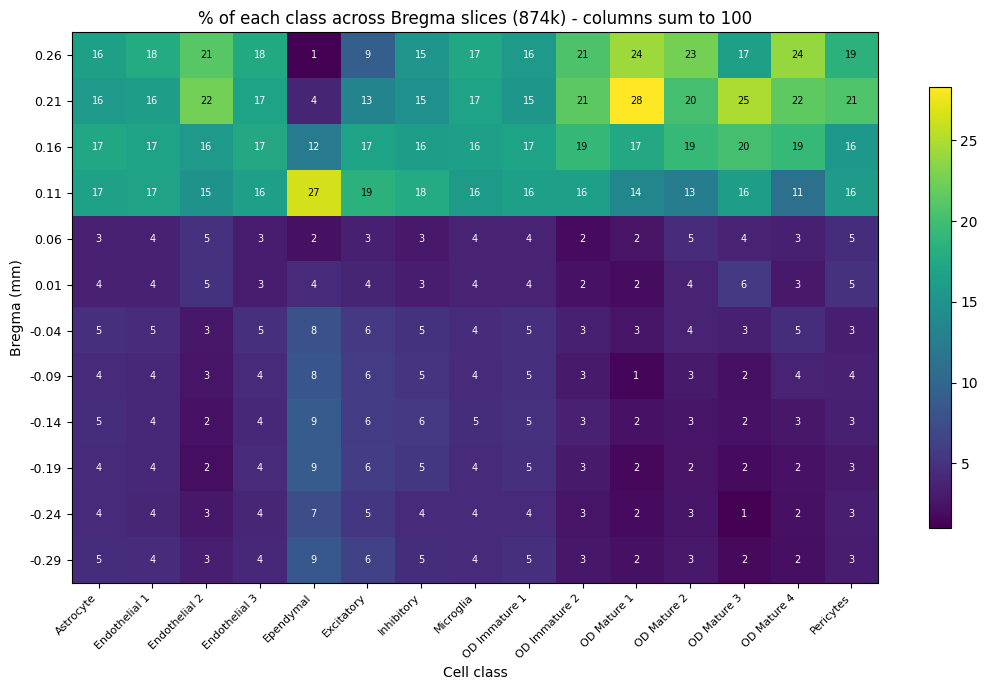

In [14]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv(TBL/"bregma_per_class_pct_across_874k.csv", index_col=0)
df = df.reindex(sorted(df.index, reverse=True))  # anterior top -> posterior bottom
fig, ax = plt.subplots(figsize=(11,7))
im = ax.imshow(df.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(df.columns))); ax.set_xticklabels(df.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(df.index)));   ax.set_yticklabels(df.index, fontsize=9)
ax.set_xlabel("Cell class"); ax.set_ylabel("Bregma (mm)")
ax.set_title("% of each class across Bregma slices (874k) - columns sum to 100")
for i in range(df.shape[0]):
    for j in range(df.shape[1]):
        v=df.values[i,j]; ax.text(j,i,f"{v:.0f}",ha="center",va="center",fontsize=7,color="white" if v<18 else "black")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.savefig(FIG/"bregma_class_heatmap_across_874k.png", dpi=160, bbox_inches="tight")
print("saved to", FIG/"bregma_class_heatmap_across_874k.png")

saved


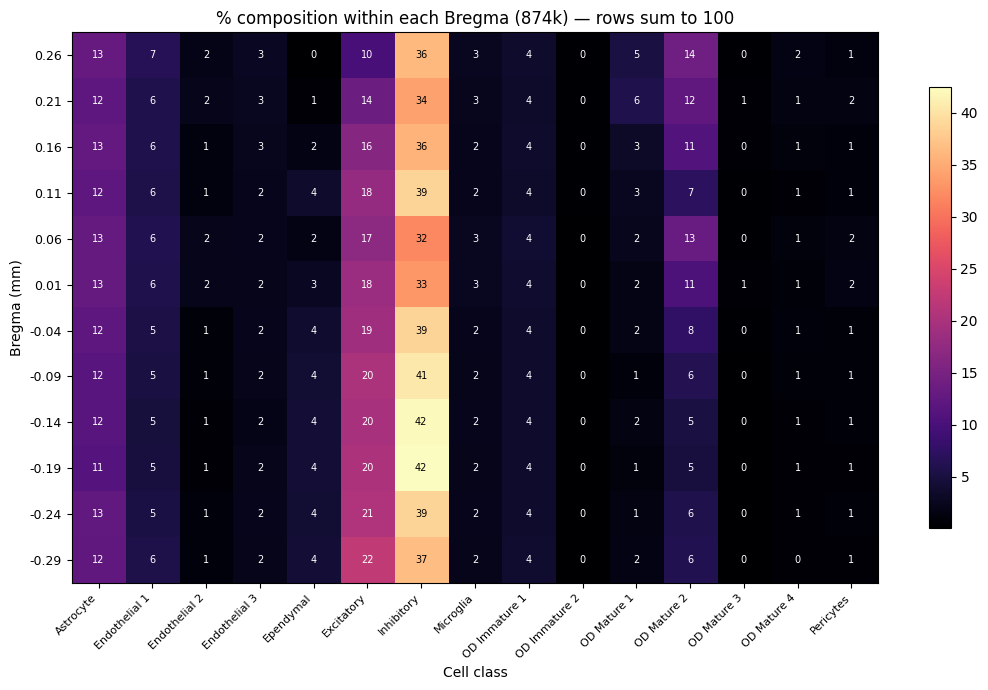

In [13]:
import pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
TBL = Path("/content/drive/MyDrive/thesis_outputs_v20/tables")
FIG = Path("/content/drive/MyDrive/thesis_outputs_v20/figures"); FIG.mkdir(exist_ok=True)
df = pd.read_csv(TBL/"bregma_per_class_pct_within_874k.csv", index_col=0).reindex(
        sorted(pd.read_csv(TBL/"bregma_per_class_pct_within_874k.csv", index_col=0).index, reverse=True))
fig, ax = plt.subplots(figsize=(11,7))
im = ax.imshow(df.values, cmap="magma", aspect="auto")
ax.set_xticks(range(len(df.columns))); ax.set_xticklabels(df.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(df.index)));   ax.set_yticklabels(df.index, fontsize=9)
ax.set_xlabel("Cell class"); ax.set_ylabel("Bregma (mm)")
ax.set_title("% composition within each Bregma (874k) — rows sum to 100")
for i in range(df.shape[0]):
    for j in range(df.shape[1]):
        v=df.values[i,j]; ax.text(j,i,f"{v:.0f}",ha="center",va="center",fontsize=7,color="white" if v<25 else "black")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.savefig(FIG/"bregma_class_heatmap_within_874k.png", dpi=160, bbox_inches="tight")
print("saved")

saved


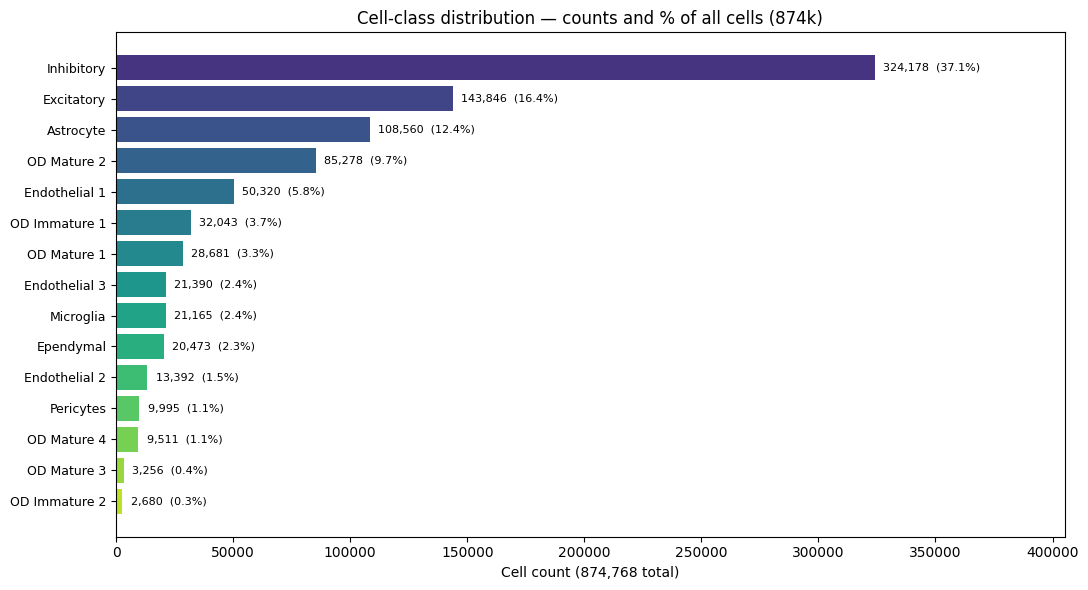

In [12]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
TBL = Path("/content/drive/MyDrive/thesis_outputs_v20/tables")
FIG = Path("/content/drive/MyDrive/thesis_outputs_v20/figures"); FIG.mkdir(exist_ok=True)

cov = pd.read_csv(TBL/"bregma_class_coverage_874k.csv", index_col=0)
counts = cov.sum(axis=0).sort_values(ascending=False)
total = counts.sum(); pct = 100*counts/total

fig, ax = plt.subplots(figsize=(11,6))
ax.barh(range(len(counts)), counts.values, color=plt.cm.viridis(np.linspace(0.15,0.9,len(counts))))
ax.set_yticks(range(len(counts))); ax.set_yticklabels(counts.index, fontsize=9); ax.invert_yaxis()
ax.set_xlabel(f"Cell count ({total:,} total)")
ax.set_title("Cell-class distribution — counts and % of all cells (874k)")
for i,(v,p) in enumerate(zip(counts.values, pct.values)):
    ax.text(v+total*0.004, i, f"{v:,}  ({p:.1f}%)", va="center", fontsize=8)
ax.set_xlim(0, counts.max()*1.25)
plt.tight_layout(); plt.savefig(FIG/"class_distribution_counts_pct_874k.png", dpi=160, bbox_inches="tight")
print("saved")